### Experiment 1: Exploratory Data Analysis and Feature Evaluation
#### Hemnath D - 3122247001022 (MTech Integrated CSE)

Aim: To perform EDA on five datasets: Iris, Loan Amount, Spambase, Diabetes and MNIST (handwritten digit images). Create functions for checking normality, finding outliers (both single column and across multiple columns together), checking missing values, correlation, variance, feature importance, mutual information and pairwise relationships. For MNIST, which is image data rather than tabular data, the same ideas (class balance, missing/corrupt samples, variance, feature importance, dimensionality) are adapted into image-specific EDA, and a Random Forest classifier is trained and evaluated on the raw pixels.

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from PIL import Image

from sklearn.datasets import load_iris, load_diabetes
from sklearn.model_selection import StratifiedKFold, KFold, cross_val_score, cross_val_predict
from sklearn.feature_selection import (
    SelectKBest, f_classif, f_regression,
    mutual_info_classif, mutual_info_regression
)
from sklearn.covariance import EmpiricalCovariance
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({
    'figure.dpi': 100,
    'savefig.dpi': 600
})

IMG_DIR = "images"
os.makedirs(IMG_DIR, exist_ok=True)

print("Setup complete.")

Setup complete.


In [2]:
def clean_name(text):
    #removes spaces
    return text.replace(' ', '_').replace('(', '').replace(')', '')

In [3]:
def save_plot(dataset, plot_type, col=None):
    name = f"expt1-{dataset}-{clean_name(col)}-{plot_type}" if col else f"expt1-{dataset}-{plot_type}"
    plt.tight_layout()
    plt.savefig(os.path.join(IMG_DIR, f"{name}.png"), dpi=600)
    plt.show()

In [4]:
def iqr_bounds(x):
    #returns the lower and upper iqr bound values
    Q1, Q3 = np.percentile(x, 25), np.percentile(x, 75)
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

In [5]:
def pick_key_columns(df, target_col=None, max_cols=5):
    #selects all numeric columns if there are 5 or fewer, otherwise picks the 5 highest variance columns
    num_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != target_col]
    if len(num_cols) <= max_cols:
        return num_cols
    return df[num_cols].var(ddof=0).nlargest(max_cols).index.tolist()

In [6]:
def check_normality(df, cols, dataset):
    #compares each column's original and standardized distribution to test normality
    for col in cols:
        x = df[col].dropna().values
        z = (x - np.mean(x)) / np.std(x)

        fig, axes = plt.subplots(1, 4, figsize=(14, 2.8))
        sns.histplot(df[col], kde=True, ax=axes[0], color='skyblue')
        axes[0].set_title(f"{col} Original")
        sns.histplot(z, kde=True, ax=axes[1], color='dodgerblue')
        axes[1].set_title("Standardized")
        sns.boxplot(data=[df[col], z], ax=axes[2], palette="Blues")
        axes[2].set_xticks([0, 1])
        axes[2].set_xticklabels(['Original', 'Scaled'])
        axes[2].set_title("Spread")
        stats.probplot(z, dist="norm", plot=axes[3])
        axes[3].set_title("Q-Q Plot")
        save_plot(dataset, "normality", col)

        w_stat, p_val = stats.shapiro(x if len(x) <= 5000 else np.random.choice(x, 5000, replace=False))
        verdict = "looks approximately normal" if p_val > 0.05 else "deviates from normality"
        print(f"Shapiro-Wilk test on '{col}': p = {p_val:.4f}, so the distribution {verdict} (alpha = 0.05)")

In [7]:
def find_outliers(df, cols, dataset):
    #univariate outliers per column using the IQR rule
    for col in cols:
        x = df[col].dropna().values
        lb, ub = iqr_bounds(x)
        n_out = int(((x < lb) | (x > ub)).sum())

        fig, axes = plt.subplots(1, 2, figsize=(9, 2.8))
        sns.boxplot(x=x, ax=axes[0], color='lightblue')
        axes[0].axvline(lb, color='red', linestyle='--')
        axes[0].axvline(ub, color='red', linestyle='--')
        axes[0].set_title(f"{col} Bounds")
        axes[1].scatter(range(len(x)), x, c=['red' if (v < lb or v > ub) else 'navy' for v in x], alpha=0.7, s=20)
        axes[1].axhline(lb, color='red', linestyle='--')
        axes[1].axhline(ub, color='red', linestyle='--')
        axes[1].set_title("Outliers Scatter")
        save_plot(dataset, "outliers", col)

        print(f"{n_out} of {len(x)} values in '{col}' are outliers (outside [{lb:.2f}, {ub:.2f}]).")

In [8]:
def find_multivariate_outliers(df, cols, dataset):
    X = df[cols].dropna().values
    m_dist = EmpiricalCovariance().fit(X).mahalanobis(X) ** 0.5
    cutoff = np.percentile(m_dist, 97.5)

    lof = LocalOutlierFactor(n_neighbors=20)
    lof_labels = lof.fit_predict(X)
    lof_scores = -lof.negative_outlier_factor_

    fig, axes = plt.subplots(1, 2, figsize=(9, 2.8))
    axes[0].scatter(range(len(m_dist)), m_dist,
                     c=['red' if d > cutoff else 'navy' for d in m_dist], s=15, alpha=0.7)
    axes[0].axhline(cutoff, color='red', linestyle='--')
    axes[0].set_title("Mahalanobis Distance")
    axes[1].scatter(range(len(lof_scores)), lof_scores,
                     c=['red' if l == -1 else 'navy' for l in lof_labels], s=15, alpha=0.7)
    axes[1].set_title("Local Outlier Factor")
    save_plot(dataset, "multivariate-outliers")

    n_maha = int((m_dist > cutoff).sum())
    n_lof = int((lof_labels == -1).sum())
    print(f"Mahalanobis distance flags {n_maha} points as outliers across correlated features; LOF flags {n_lof} points as locally isolated")

In [9]:
def cap_outliers(df, cols, dataset, lower_pct=0.05, upper_pct=0.95):
    #caps extreme values at the 5th/95th percentile (winsorization) instead of deleting them
    for col in cols:
        x = df[col].dropna().values
        x_win = np.clip(x, np.percentile(x, lower_pct * 100), np.percentile(x, upper_pct * 100))
        pct_changed = 100 * np.mean(x != x_win)

        fig, axes = plt.subplots(1, 2, figsize=(8, 2.6))
        sns.boxplot(x=df[col], ax=axes[0], color='plum')
        axes[0].set_title(f"{col} Original")
        sns.boxplot(x=x_win, ax=axes[1], color='orchid')
        axes[1].set_title(f"{col} Winsorized")
        save_plot(dataset, "winsorization", col)

        print(f"Winsorizing '{col}' capped {pct_changed:.1f}% of values, reducing the spread of {x.max()-x.min():.2f}")

In [10]:
def check_missing_values(df, dataset):
    # Shows where values are missing and how many are missing per column
    total_missing = df.isnull().sum()
    overall_pct = 100 * df.isnull().values.sum() / df.size

    fig, axes = plt.subplots(1, 2, figsize=(10, 3.0))
    sns.heatmap(df.isnull(), cbar=False, cmap="binary", ax=axes[0], yticklabels=False)
    axes[0].set_title("Missing Matrix")
    axes[1].bar(total_missing.index[:10], total_missing.values[:10], color='crimson', alpha=0.7)
    axes[1].set_title("Missing Count")
    axes[1].set_xticks(range(len(total_missing.index[:10])))
    axes[1].set_xticklabels(total_missing.index[:10], rotation=30, ha='right')
    save_plot(dataset, "missing")

    print(f"Overall missing rate is {overall_pct:.2f}% across all cells\n{int((total_missing > 0).sum())} column(s) contain missing values")

In [11]:
def plot_correlation(df, dataset):
    # Computes the Pearson correlation matrix across all numeric features
    num_cols = df.select_dtypes(include=[np.number]).columns
    corr = df[num_cols].corr()

    plt.figure(figsize=(7, 5.5) if len(num_cols) <= 10 else (16, 14))
    sns.heatmap(corr, annot=(len(num_cols) <= 10), fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
                xticklabels=True, yticklabels=True)
    if len(num_cols) > 10:
        plt.xticks(rotation=90, fontsize=7)
        plt.yticks(rotation=0, fontsize=7)
    plt.title(f"Correlation Heatmap ({dataset})")
    save_plot(dataset, "correlation")

    tri = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    top_pair = tri.stack().abs().idxmax()
    top_val = tri.loc[top_pair]
    print(f"Strongest pairwise correlation is between '{top_pair[0]}' and '{top_pair[1]}' (r = {top_val:.2f})")

In [12]:
def check_variance(df, target_col, dataset, threshold=0.1):
    # Computes variance for every feature and flags ones below a low-variance threshold
    X = df.drop(columns=[target_col])
    variances = X.var(ddof=0)

    plt.figure(figsize=(8, 3.5) if len(variances) <= 10 else (14, 4.0))
    plt.bar(variances.index, variances.values, color='teal', alpha=0.7)
    plt.axhline(threshold, color='red', linestyle='--', label=f'Threshold ({threshold})')
    plt.title(f"Feature Variances ({dataset})")
    plt.ylabel("Variance")
    plt.xticks(rotation=90 if len(variances) > 10 else 25, ha='right', fontsize=7 if len(variances) > 10 else 9)
    plt.legend()
    save_plot(dataset, "variance")

    n_low = int((variances < threshold).sum())
    print(f"{n_low} of {len(variances)} features fall below the variance threshold of {threshold}")

In [13]:
def rank_features(df, target_col, score_func, dataset):
    #ranks every feature by its univariate statistical relationship with the target
    X = df.drop(columns=[target_col])
    y = df[target_col]
    selector = SelectKBest(score_func=score_func, k='all').fit(X, y)
    score_df = pd.DataFrame({"Feature": list(X.columns), "Score": selector.scores_}).sort_values(by="Score", ascending=False)

    plt.figure(figsize=(8, 3.5) if len(score_df) <= 10 else (10, 8.0))
    plot_df = score_df.head(15) if len(score_df) > 15 else score_df
    sns.barplot(data=plot_df, x="Score", y="Feature", hue="Feature", palette="viridis", legend=False)
    plt.title(f"Feature Importance ({dataset})")
    plt.xlabel("Score")
    save_plot(dataset, "importance")

    top = score_df.iloc[0]
    print(f"'{top['Feature']}' has the strongest relationship with the target (score: {top['Score']:.2f})")

In [14]:
def rank_mutual_info(df, target_col, dataset, task='classification'):
    #ranks features by mutual information which also captures non linear relationships with the target
    X = df.drop(columns=[target_col])
    y = df[target_col]
    scorer = mutual_info_classif if task == 'classification' else mutual_info_regression
    scores = scorer(X, y, random_state=0)
    score_df = pd.DataFrame({"Feature": X.columns, "Score": scores}).sort_values(by="Score", ascending=False)

    plt.figure(figsize=(8, 3.5) if len(score_df) <= 10 else (10, 8.0))
    plot_df = score_df.head(15) if len(score_df) > 15 else score_df
    sns.barplot(data=plot_df, x="Score", y="Feature", hue="Feature", palette="mako", legend=False)
    plt.title(f"Mutual Information ({dataset})")
    plt.xlabel("Mutual Information Score")
    save_plot(dataset, "mutual-info")

    top = score_df.iloc[0]
    print(f"'{top['Feature']}' shares the most information with the target ({top['Score']:.3f})")

In [15]:
def plot_pairwise(df, cols, target_col, dataset):
    #shows every pairwise scatter relationship between the selected columns
    plot_cols = cols + [target_col]
    g = sns.pairplot(df[plot_cols], hue=target_col, palette="deep", diag_kind='kde', plot_kws={'alpha': 0.6, 's': 15})
    g.fig.suptitle(f"Pairwise Relationships ({dataset})", y=1.02)
    plt.savefig(os.path.join(IMG_DIR, f"expt1-{dataset}-pairwise.png"), dpi=600, bbox_inches='tight')
    plt.show()

In [16]:
def standardize_column(df, col):
    x = df[col].values
    return (x - np.mean(x)) / np.std(x)

In [17]:
def normalize_column(df, col):
    x = df[col].values
    return (x - x.min()) / (x.max() - x.min())

In [18]:
def compare_scaling(df, col, dataset):
    x = df[col].values
    z = standardize_column(df, col)
    n = normalize_column(df, col)

    fig, axes = plt.subplots(1, 3, figsize=(11, 2.8))
    sns.histplot(x, kde=True, ax=axes[0], color='slateblue')
    axes[0].set_title(f"{col} Original")
    sns.histplot(z, kde=True, ax=axes[1], color='mediumseagreen')
    axes[1].set_title("Standardized (mean 0, sd 1)")
    sns.histplot(n, kde=True, ax=axes[2], color='darkorange')
    axes[2].set_title("Normalized ([0, 1])")
    save_plot(dataset, "scaling", col)

    print(f"'{col}' now has mean {z.mean():.2f}/std {z.std():.2f} after standardization and range [{n.min():.0f}, {n.max():.0f}] after normalization.")

In [19]:
def fill_missing_values(df, col, method='median'):
    df = df.copy()
    if df[col].dtype.kind in 'ifc':
        fill_value = df[col].mean() if method == 'mean' else df[col].median()
    else:
        fill_value = df[col].mode().iloc[0]
        method = 'mode'
    df[col] = df[col].fillna(fill_value)
    print(f"Filled missing values in '{col}' using the {method} ({fill_value:.2f} if numeric).")
    return df

In [20]:
def encode_categories(df, col):
    df = df.copy()
    df[col] = df[col].astype('category').cat.codes
    print(f"Encoded categorical column '{col}' into {df[col].nunique()}")
    return df

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score, r2_score, mean_squared_error,
    precision_score, recall_score, f1_score, confusion_matrix
)

In [22]:
def evaluate_classification_knn(df, target_col, dataset, k_range=range(1, 21), cv_folds=5,
                                 random_state=42, rf_estimators=200):
    #uses stratified k-fold cross validation instead of a single train/test split, since a
    #single 80/20 split on a small dataset like iris can land on an unusually easy (or hard)
    #test set just by chance. every sample gets used as test data exactly once across the folds,
    #so the reported score reflects the whole dataset rather than one lucky/unlucky split
    X = df.drop(columns=[target_col]).reset_index(drop=True)
    y = df[target_col].reset_index(drop=True)
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)

    cv_means, cv_stds = [], []
    for k in k_range:
        knn = KNeighborsClassifier(n_neighbors=k)
        scores = cross_val_score(knn, X, y, cv=cv, scoring='accuracy')
        cv_means.append(scores.mean())
        cv_stds.append(scores.std())

    best_idx = int(np.argmax(cv_means))
    best_k = list(k_range)[best_idx]
    best_acc = cv_means[best_idx]

    plt.figure(figsize=(6, 3.5))
    plt.errorbar(list(k_range), cv_means, yerr=cv_stds, marker='o', color='slateblue',
                 ecolor='lightsteelblue', capsize=3)
    plt.scatter([best_k], [best_acc], color='crimson', zorder=5,
                label=f"best k={best_k} ({best_acc:.3f})")
    plt.xlabel("k (n_neighbors)")
    plt.ylabel(f"{cv_folds}-Fold CV Accuracy")
    plt.title(f"{dataset}: KNN Cross-Validated Accuracy vs k")
    plt.legend()
    save_plot(dataset, "knn_k_vs_accuracy")

    #out-of-fold predictions at the best k, so every sample contributes one honest prediction
    best_knn = KNeighborsClassifier(n_neighbors=best_k)
    knn_cv_preds = cross_val_predict(best_knn, X, y, cv=cv)

    #random forest evaluated the same way for a fair comparison
    rf = RandomForestClassifier(n_estimators=rf_estimators, random_state=random_state)
    rf_cv_preds = cross_val_predict(rf, X, y, cv=cv)

    def metrics_row(y_true, y_pred):
        return {
            "Accuracy": accuracy_score(y_true, y_pred),
            "Precision": precision_score(y_true, y_pred, average='weighted', zero_division=0),
            "Recall": recall_score(y_true, y_pred, average='weighted', zero_division=0),
            "F1 Score": f1_score(y_true, y_pred, average='weighted', zero_division=0),
        }

    knn_name = f"KNN (k={best_k})"
    rf_name = f"Random Forest ({rf_estimators} trees)"
    metrics_df = pd.DataFrame({
        knn_name: metrics_row(y, knn_cv_preds),
        rf_name: metrics_row(y, rf_cv_preds),
    }).T
    metrics_df.index.name = "Model"

    #grouped bar chart comparing every metric across both models
    fig, ax = plt.subplots(figsize=(7, 3.8))
    metrics_df.plot(kind='bar', ax=ax, colormap='viridis', width=0.75)
    ax.set_title(f"{dataset}: Model Comparison ({cv_folds}-Fold CV)")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.08)
    ax.legend(loc='lower right', fontsize=8)
    plt.xticks(rotation=15, ha='right')
    save_plot(dataset, "model_comparison")

    #confusion matrices built from the out-of-fold predictions for both models
    labels = sorted(y.unique())
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax_, preds_, name_ in zip(axes, [knn_cv_preds, rf_cv_preds], [knn_name, rf_name]):
        cm = confusion_matrix(y, preds_, labels=labels)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax_,
                    xticklabels=labels, yticklabels=labels, cbar=False)
        ax_.set_title(name_)
        ax_.set_xlabel("Predicted")
        ax_.set_ylabel("Actual")
    save_plot(dataset, "confusion_matrices")

    #fit each model on the full dataset and compare training accuracy against the cross
    #validated accuracy above, as a quick check for overfitting
    best_knn.fit(X, y)
    knn_train_acc = accuracy_score(y, best_knn.predict(X))
    rf.fit(X, y)
    rf_train_acc = accuracy_score(y, rf.predict(X))

    winner = metrics_df['Accuracy'].idxmax()
    print(f"[{dataset}] Best k = {best_k}. '{winner}' has the higher cross validated accuracy "
          f"({metrics_df['Accuracy'].max():.4f} vs {metrics_df['Accuracy'].min():.4f}).")
    print(f"[{dataset}] Overfitting check: KNN train accuracy {knn_train_acc:.4f} vs {cv_folds}-fold "
          f"CV accuracy {metrics_df.loc[knn_name, 'Accuracy']:.4f} (gap {knn_train_acc - metrics_df.loc[knn_name, 'Accuracy']:.4f})")
    print(f"[{dataset}] Overfitting check: Random Forest train accuracy {rf_train_acc:.4f} vs {cv_folds}-fold "
          f"CV accuracy {metrics_df.loc[rf_name, 'Accuracy']:.4f} (gap {rf_train_acc - metrics_df.loc[rf_name, 'Accuracy']:.4f})")
    display(metrics_df.style.format("{:.4f}"))

    return best_k, metrics_df


In [23]:
def evaluate_regression_linear(df, target_col, dataset, cv_folds=5, random_state=42, rf_estimators=200):
    #same reasoning as the classification version: a single train/test split on datasets
    #this small can be noisy, so k-fold cross validation is used to get a more trustworthy
    #estimate of how each model actually generalizes
    X = df.drop(columns=[target_col]).reset_index(drop=True)
    y = df[target_col].reset_index(drop=True)
    cv = KFold(n_splits=cv_folds, shuffle=True, random_state=random_state)

    lin = LinearRegression()
    rf = RandomForestRegressor(n_estimators=rf_estimators, random_state=random_state, n_jobs=-1)

    lin_preds = cross_val_predict(lin, X, y, cv=cv)
    rf_preds = cross_val_predict(rf, X, y, cv=cv)

    def scores(y_true, y_pred):
        return r2_score(y_true, y_pred), mean_squared_error(y_true, y_pred) ** 0.5

    lin_r2, lin_rmse = scores(y, lin_preds)
    rf_r2, rf_rmse = scores(y, rf_preds)

    lin_name, rf_name = "Linear Regression", f"Random Forest ({rf_estimators} trees)"
    metrics_df = pd.DataFrame({
        lin_name: {"R2": lin_r2, "RMSE": lin_rmse},
        rf_name: {"R2": rf_r2, "RMSE": rf_rmse},
    }).T
    metrics_df.index.name = "Model"

    #actual vs predicted, using the out-of-fold predictions for both models
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
    for ax_, preds_, name_, color_ in zip(axes, [lin_preds, rf_preds], [lin_name, rf_name], ['slateblue', 'seagreen']):
        lims = [min(y.min(), preds_.min()), max(y.max(), preds_.max())]
        ax_.scatter(y, preds_, alpha=0.5, color=color_, s=15)
        ax_.plot(lims, lims, color='crimson', linestyle='--')
        ax_.set_xlabel("Actual")
        ax_.set_ylabel("Predicted")
        ax_.set_title(f"{dataset}: {name_}")
    save_plot(dataset, "actual_vs_predicted_comparison")

    #R2 / RMSE comparison bars
    fig, axes = plt.subplots(1, 2, figsize=(9, 3.3))
    colors = ['slateblue', 'seagreen']
    axes[0].bar(metrics_df.index, metrics_df['R2'], color=colors)
    axes[0].set_title(f"{dataset}: R\u00b2 Comparison (higher is better)")
    axes[0].set_ylim(min(0, metrics_df['R2'].min() - 0.05), 1.0)
    axes[1].bar(metrics_df.index, metrics_df['RMSE'], color=colors)
    axes[1].set_title(f"{dataset}: RMSE Comparison (lower is better)")
    for ax_ in axes:
        ax_.tick_params(axis='x', rotation=12)
    save_plot(dataset, "metric_comparison")

    #residual distribution overlay
    fig, ax = plt.subplots(figsize=(7, 3.2))
    sns.kdeplot(y - lin_preds, label=lin_name, fill=True, alpha=0.3, ax=ax, color='slateblue')
    sns.kdeplot(y - rf_preds, label=rf_name, fill=True, alpha=0.3, ax=ax, color='seagreen')
    ax.axvline(0, color='crimson', linestyle='--')
    ax.set_title(f"{dataset}: Residual Distribution")
    ax.set_xlabel("Residual (Actual - Predicted)")
    ax.legend(fontsize=8)
    save_plot(dataset, "residual_distribution")

    #fit on the full data and compare training R2 against the cross validated R2 to check for overfitting
    lin.fit(X, y)
    lin_train_r2 = r2_score(y, lin.predict(X))
    rf.fit(X, y)
    rf_train_r2 = r2_score(y, rf.predict(X))

    winner = metrics_df['R2'].idxmax()
    print(f"[{dataset}] Linear Regression: R2={lin_r2:.4f}, RMSE={lin_rmse:.4f} | "
          f"Random Forest: R2={rf_r2:.4f}, RMSE={rf_rmse:.4f}. '{winner}' explains more variance across the {cv_folds} folds.")
    print(f"[{dataset}] Overfitting check: Linear Regression train R2 {lin_train_r2:.4f} vs cross validated R2 {lin_r2:.4f} "
          f"(gap {lin_train_r2 - lin_r2:.4f})")
    print(f"[{dataset}] Overfitting check: Random Forest train R2 {rf_train_r2:.4f} vs cross validated R2 {rf_r2:.4f} "
          f"(gap {rf_train_r2 - rf_r2:.4f})")
    display(metrics_df.style.format("{:.4f}"))

    return metrics_df


In [24]:
#Iris(classification)
iris = load_iris()
df_iris = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df_iris['target'] = iris.target

#Loan Amount(regression)
df_loan = pd.read_csv('loan_amount.csv')

#Spambase(classification)
df_spam = pd.read_csv('spambase.csv')

#Diabetes(regression)
diabetes = load_diabetes()
df_diab = pd.DataFrame(data=diabetes.data, columns=diabetes.feature_names)
df_diab['target'] = diabetes.target

#MNIST(image classification) - loaded further down in its own section since it
#needs image-specific loading/EDA rather than a plain DataFrame

print("Iris:", df_iris.shape, "\nLoan:", df_loan.shape, "\nSpam:", df_spam.shape, "\nDiabetes:", df_diab.shape)

Iris: (150, 5) 
Loan: (500, 9) 
Spam: (4601, 58) 
Diabetes: (442, 11)


### Iris dataset
this is a small, clean dataset, so running normality, outliers, missing values, correlation, variance, feature importance, mutual information and pairwise plots on it

In [25]:
cols_iris = pick_key_columns(df_iris, target_col='target', max_cols=5)
print("Selected columns for Iris:", cols_iris)

Selected columns for Iris: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


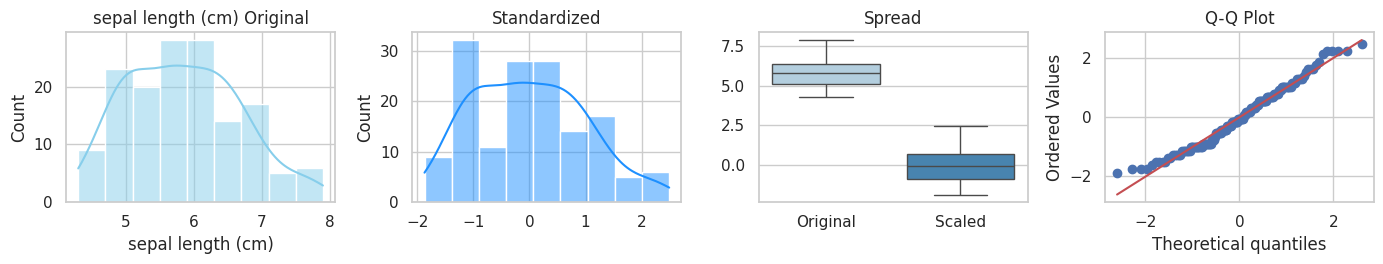

Shapiro-Wilk test on 'sepal length (cm)': p = 0.0102, so the distribution deviates from normality (alpha = 0.05)


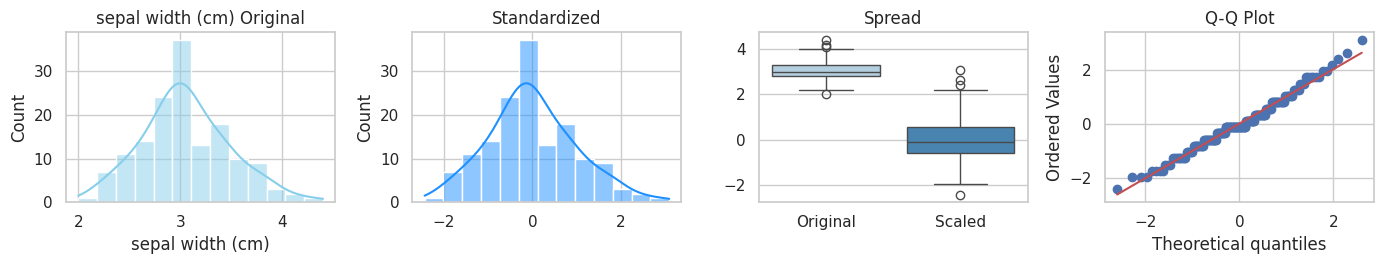

Shapiro-Wilk test on 'sepal width (cm)': p = 0.1012, so the distribution looks approximately normal (alpha = 0.05)


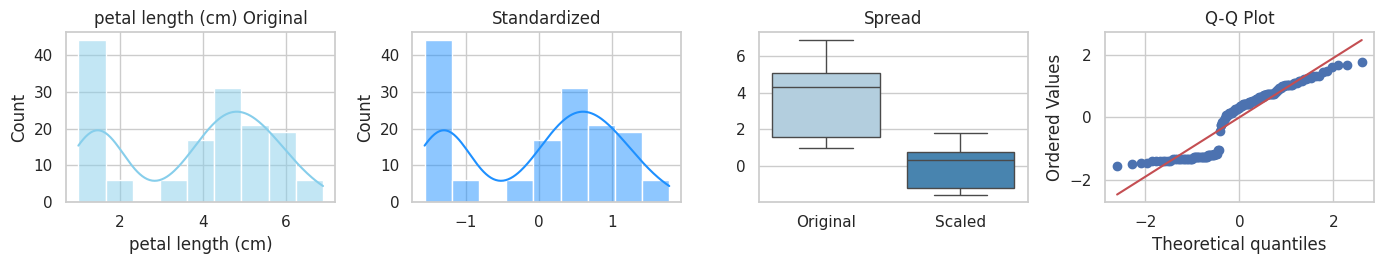

Shapiro-Wilk test on 'petal length (cm)': p = 0.0000, so the distribution deviates from normality (alpha = 0.05)


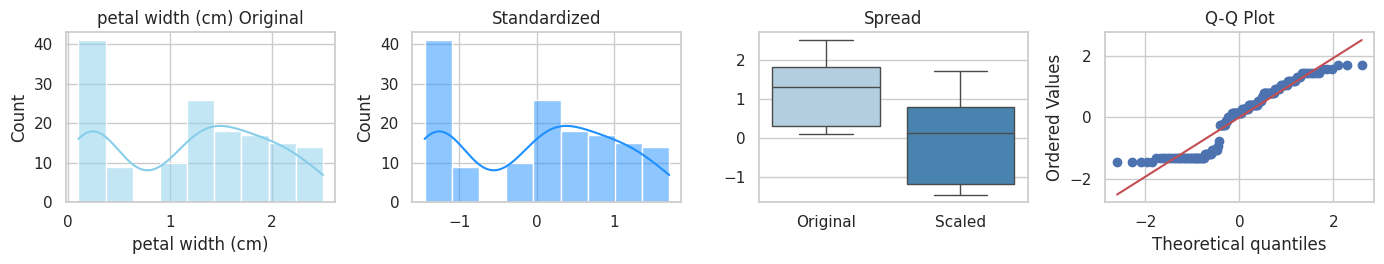

Shapiro-Wilk test on 'petal width (cm)': p = 0.0000, so the distribution deviates from normality (alpha = 0.05)


In [26]:
check_normality(df_iris, cols_iris, 'iris')

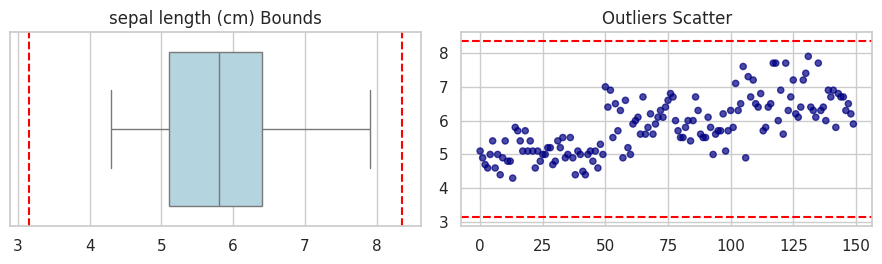

0 of 150 values in 'sepal length (cm)' are outliers (outside [3.15, 8.35]).


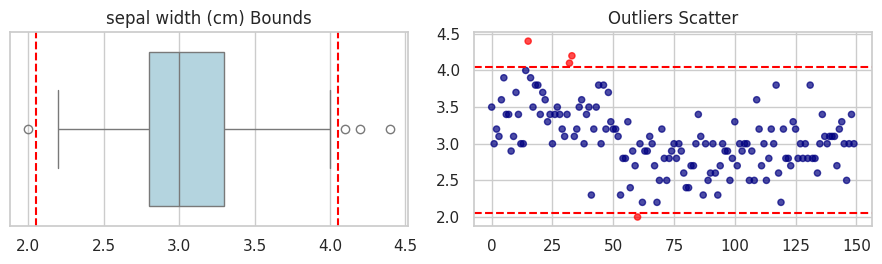

4 of 150 values in 'sepal width (cm)' are outliers (outside [2.05, 4.05]).


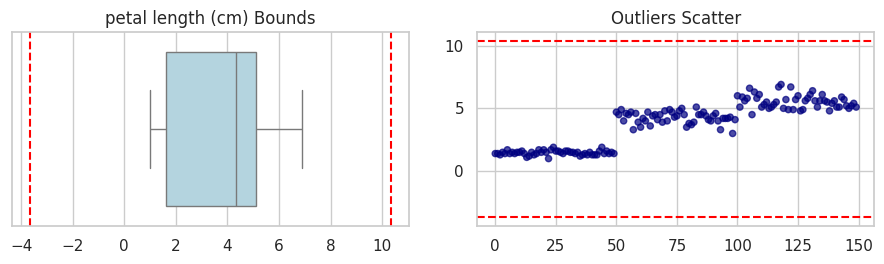

0 of 150 values in 'petal length (cm)' are outliers (outside [-3.65, 10.35]).


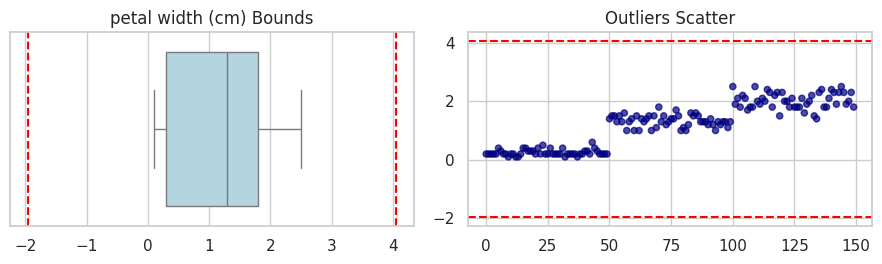

0 of 150 values in 'petal width (cm)' are outliers (outside [-1.95, 4.05]).


In [27]:
find_outliers(df_iris, cols_iris, 'iris')

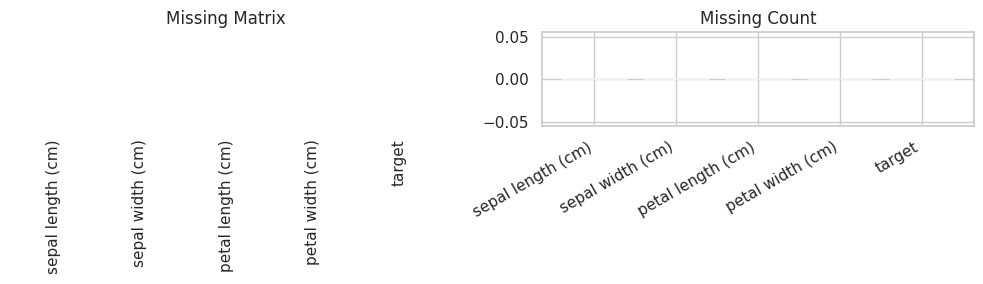

Overall missing rate is 0.00% across all cells
0 column(s) contain missing values


In [28]:
check_missing_values(df_iris, 'iris')

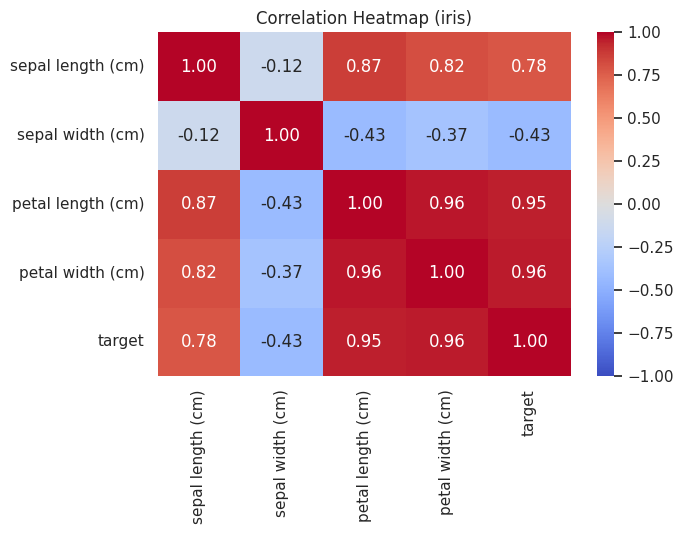

Strongest pairwise correlation is between 'petal length (cm)' and 'petal width (cm)' (r = 0.96)


In [29]:
plot_correlation(df_iris, 'iris')

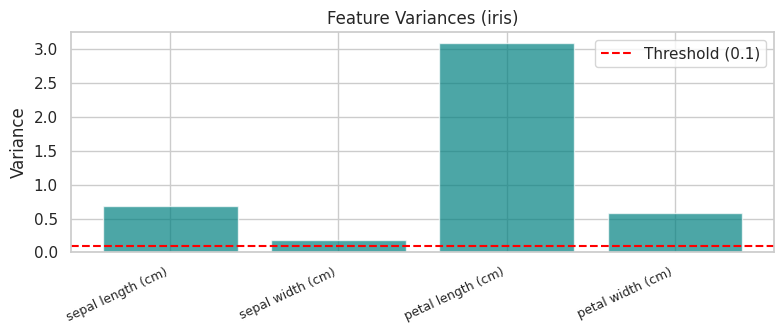

0 of 4 features fall below the variance threshold of 0.1


In [30]:
check_variance(df_iris, 'target', 'iris')

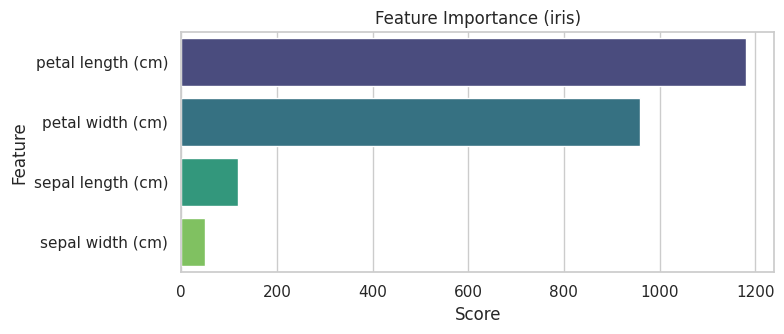

'petal length (cm)' has the strongest relationship with the target (score: 1180.16)


In [31]:
rank_features(df_iris, 'target', f_classif, 'iris')

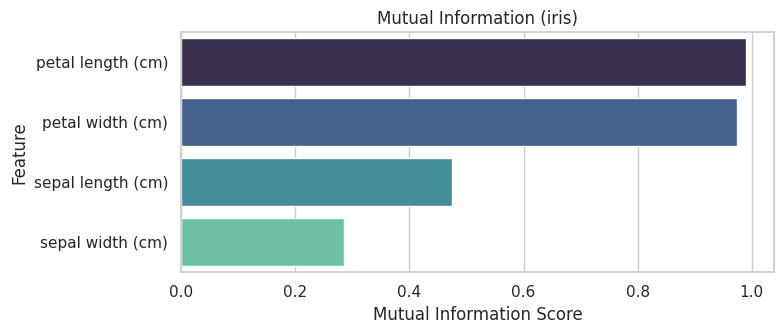

'petal length (cm)' shares the most information with the target (0.990)


In [32]:
rank_mutual_info(df_iris, 'target', 'iris', task='classification')

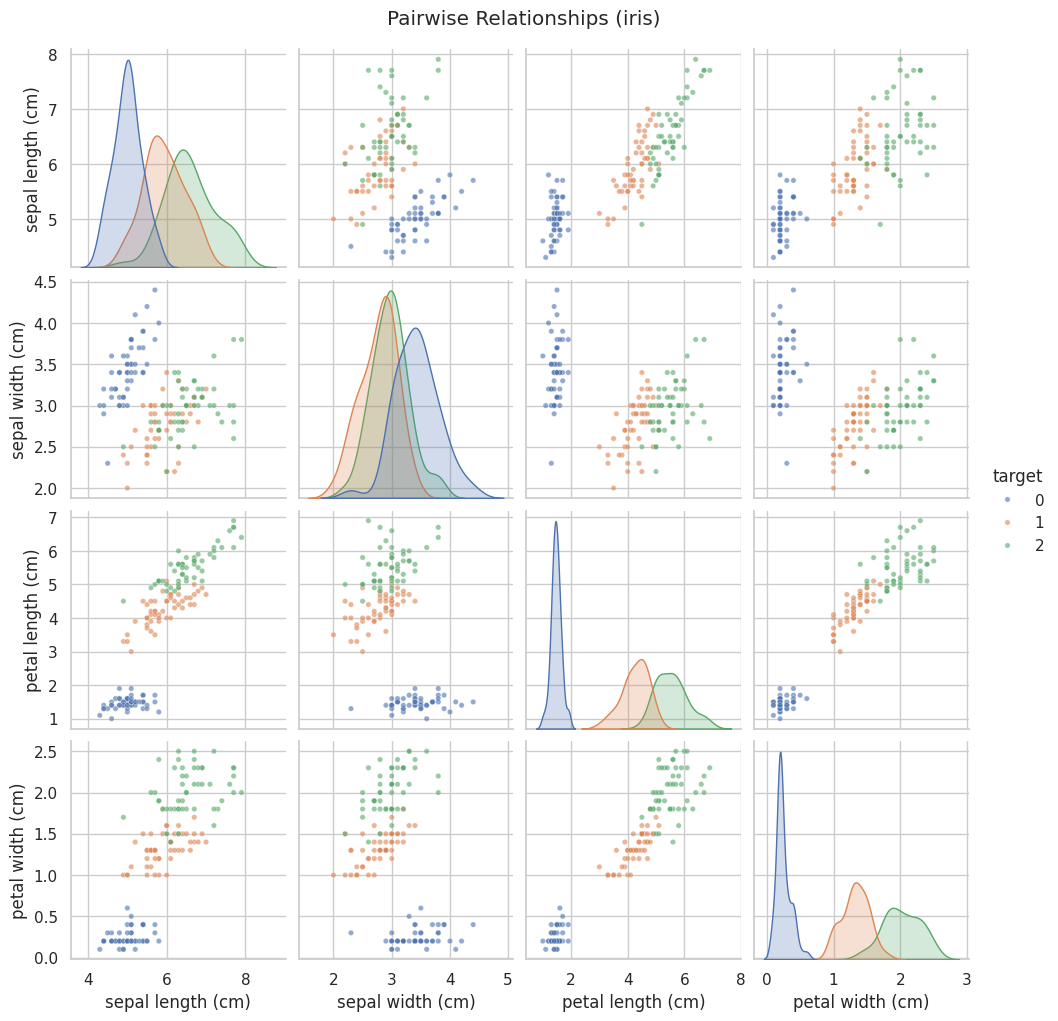

In [33]:
plot_pairwise(df_iris, cols_iris, 'target', 'iris')

#### Cleaning


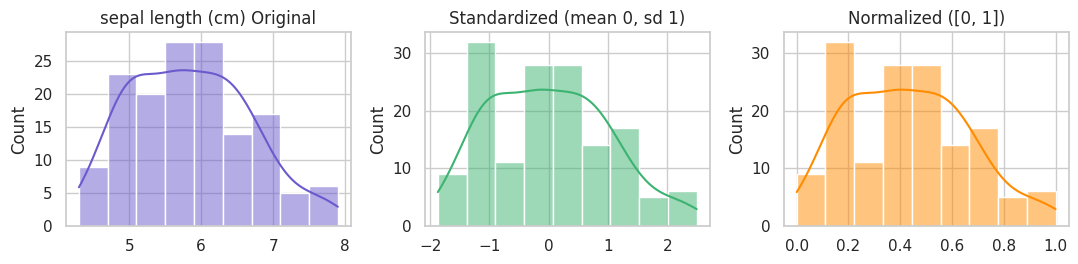

'sepal length (cm)' now has mean -0.00/std 1.00 after standardization and range [0, 1] after normalization.


In [34]:
compare_scaling(df_iris, cols_iris[0], 'iris')

### Evaluating Models
basic KNN classifier, sweeping k and evaluating test accuracy

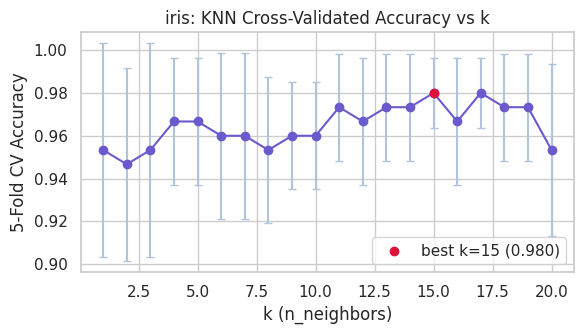

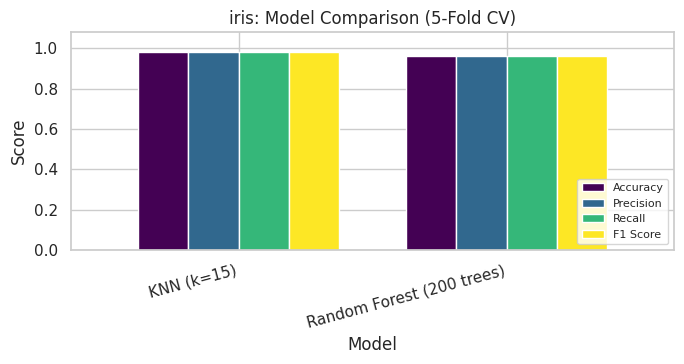

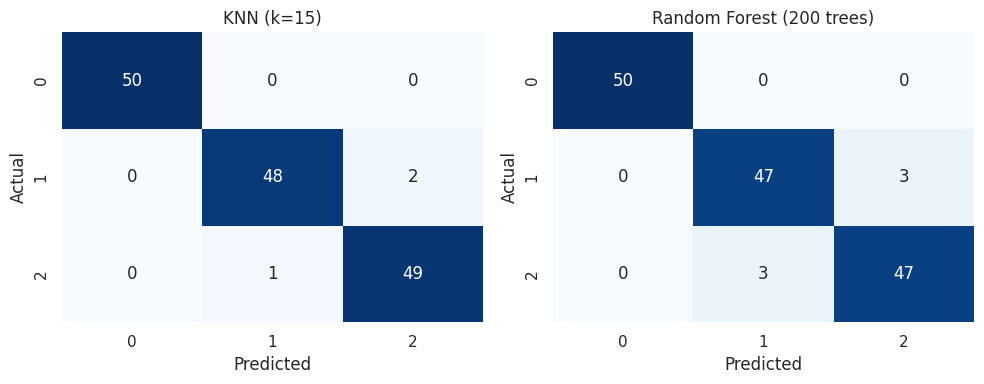

[iris] Best k = 15. 'KNN (k=15)' has the higher cross validated accuracy (0.9800 vs 0.9600).
[iris] Overfitting check: KNN train accuracy 0.9867 vs 5-fold CV accuracy 0.9800 (gap 0.0067)
[iris] Overfitting check: Random Forest train accuracy 1.0000 vs 5-fold CV accuracy 0.9600 (gap 0.0400)


,Accuracy,Precision,Recall,F1 Score
Model,,,,
KNN (k=15),0.9800,0.9801,0.9800,0.9800
Random Forest (200 trees),0.9600,0.9600,0.9600,0.9600


(15,
                            Accuracy  Precision  Recall  F1 Score
 Model                                                           
 KNN (k=15)                     0.98   0.980125    0.98  0.979998
 Random Forest (200 trees)      0.96   0.960000    0.96  0.960000)

In [35]:
evaluate_classification_knn(df_iris, 'target', 'iris')

### Loan Amount dataset(regression)

In [36]:
cols_loan = pick_key_columns(df_loan, target_col='loan_amount', max_cols=5)
print("Selected columns for Loan Amount:", cols_loan)

Selected columns for Loan Amount: ['credit_score', 'coapplicant_income', 'property_area_code', 'assets_value', 'applicant_income']


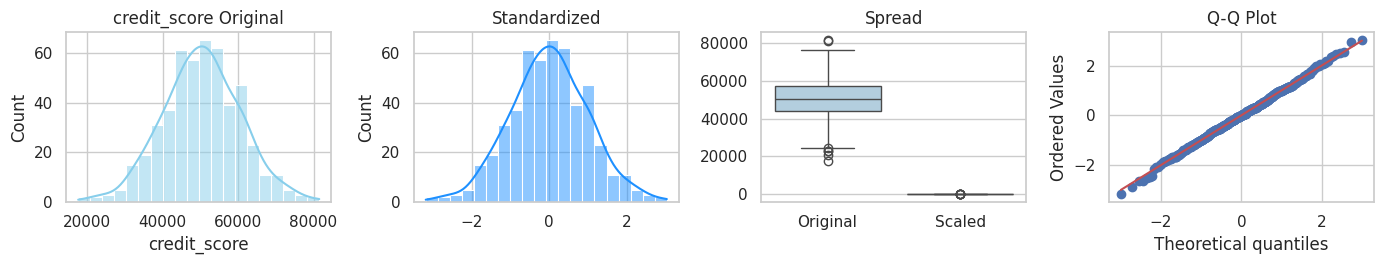

Shapiro-Wilk test on 'credit_score': p = 0.9583, so the distribution looks approximately normal (alpha = 0.05)


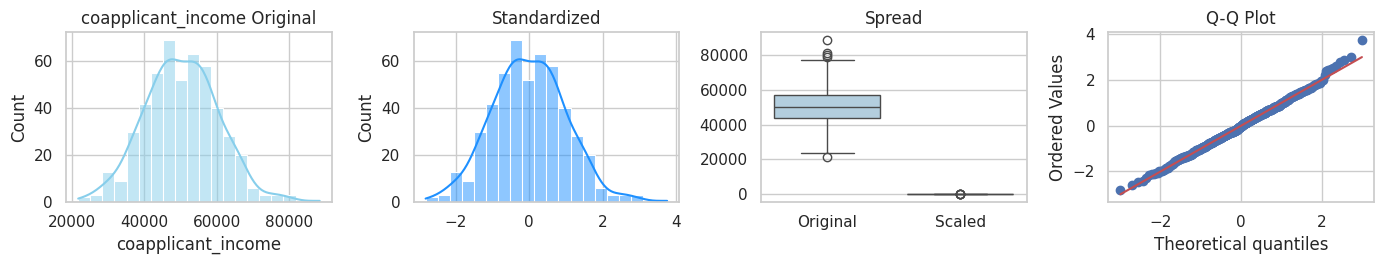

Shapiro-Wilk test on 'coapplicant_income': p = 0.4637, so the distribution looks approximately normal (alpha = 0.05)


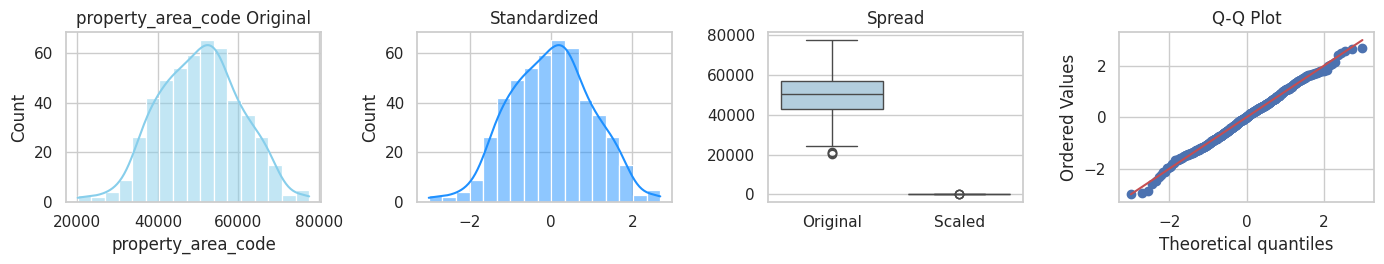

Shapiro-Wilk test on 'property_area_code': p = 0.4020, so the distribution looks approximately normal (alpha = 0.05)


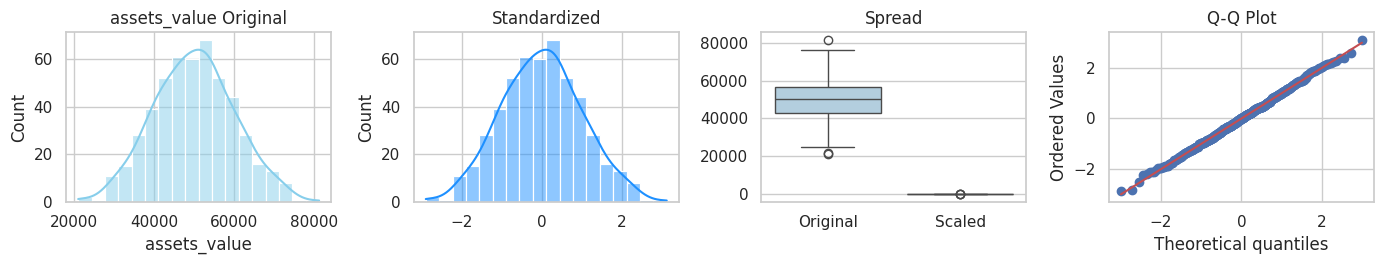

Shapiro-Wilk test on 'assets_value': p = 0.9739, so the distribution looks approximately normal (alpha = 0.05)


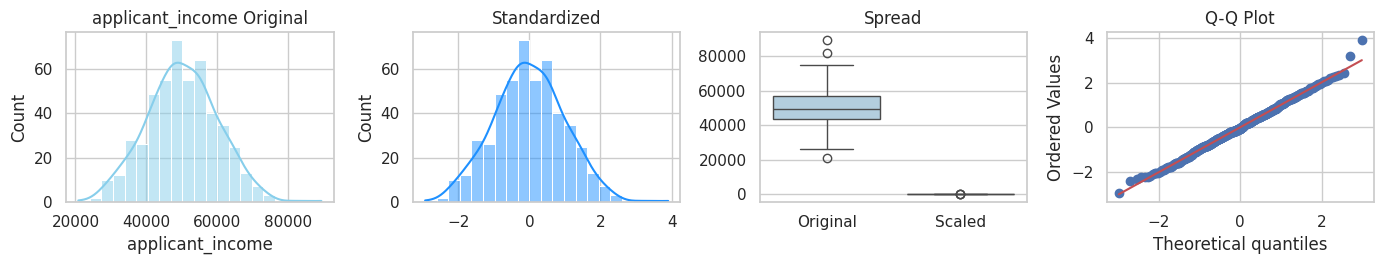

Shapiro-Wilk test on 'applicant_income': p = 0.6491, so the distribution looks approximately normal (alpha = 0.05)


In [37]:
check_normality(df_loan, cols_loan, 'loan')

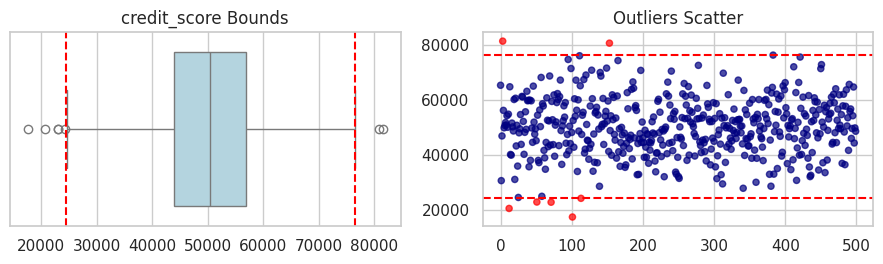

7 of 500 values in 'credit_score' are outliers (outside [24401.15, 76506.43]).


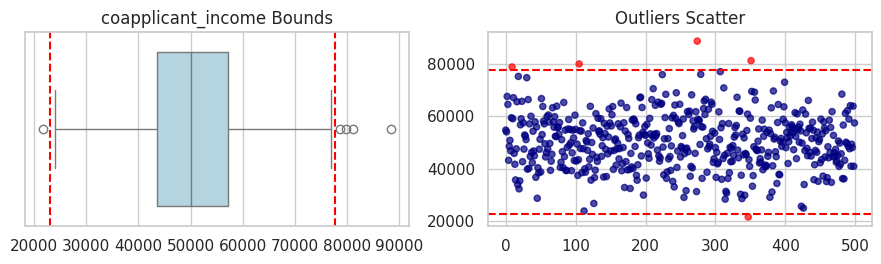

5 of 500 values in 'coapplicant_income' are outliers (outside [22974.00, 77698.85]).


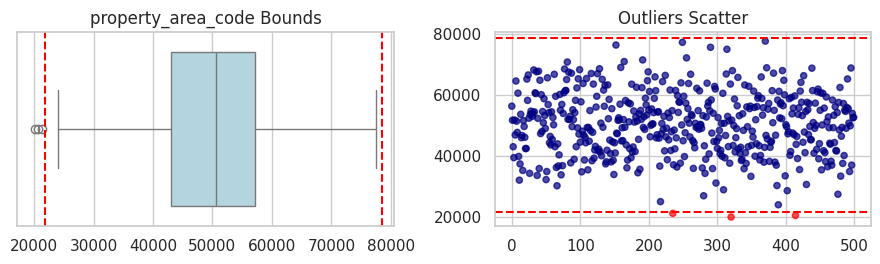

3 of 500 values in 'property_area_code' are outliers (outside [21828.51, 78484.70]).


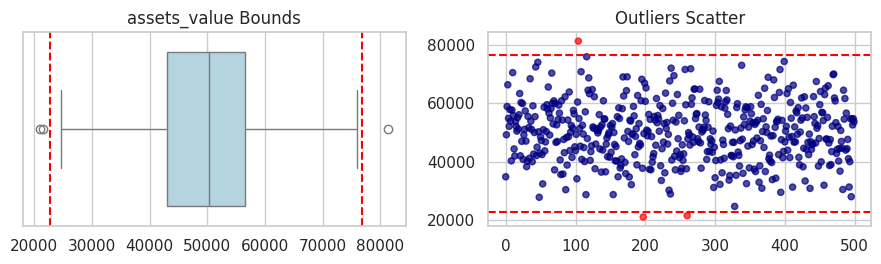

3 of 500 values in 'assets_value' are outliers (outside [22847.27, 76782.95]).


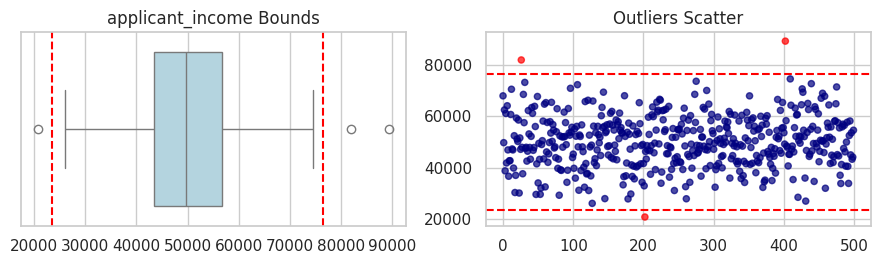

3 of 500 values in 'applicant_income' are outliers (outside [23582.47, 76503.00]).


In [38]:
find_outliers(df_loan, cols_loan, 'loan')

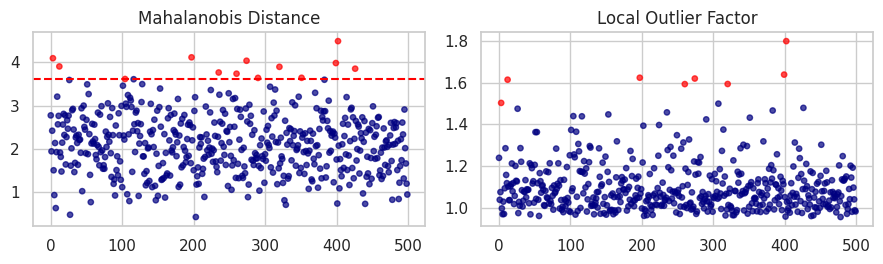

Mahalanobis distance flags 13 points as outliers across correlated features; LOF flags 8 points as locally isolated


In [39]:
find_multivariate_outliers(df_loan, cols_loan, 'loan')

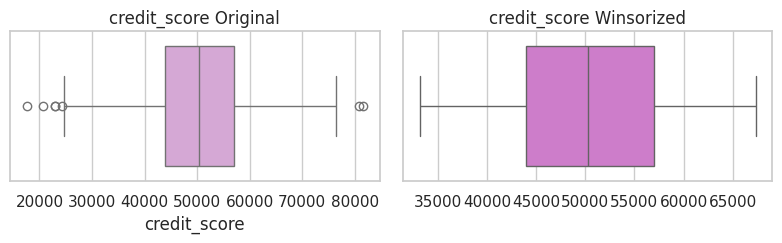

Winsorizing 'credit_score' capped 10.0% of values, reducing the spread of 63933.24


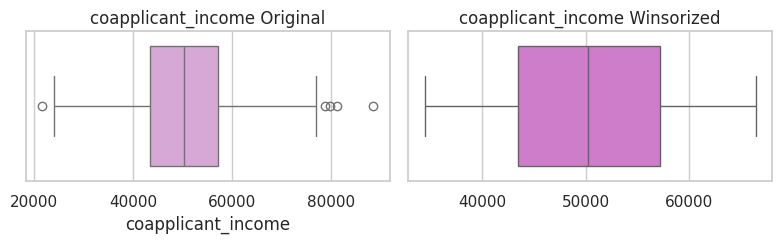

Winsorizing 'coapplicant_income' capped 10.0% of values, reducing the spread of 66848.87


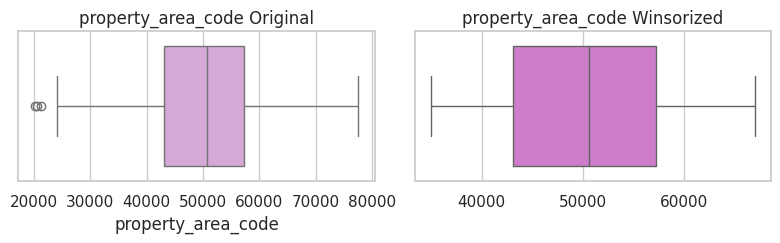

Winsorizing 'property_area_code' capped 10.0% of values, reducing the spread of 57507.96


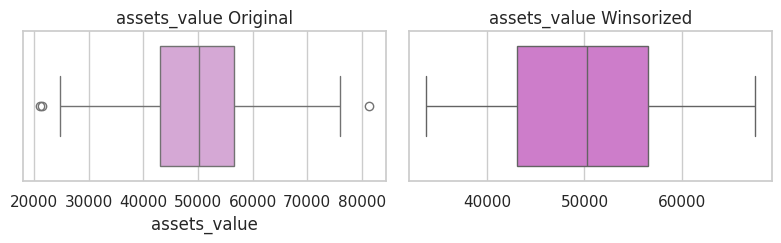

Winsorizing 'assets_value' capped 10.0% of values, reducing the spread of 60340.04


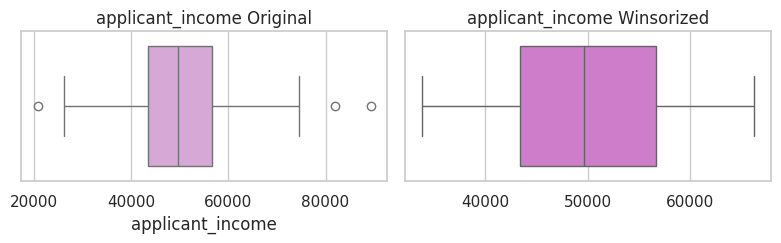

Winsorizing 'applicant_income' capped 10.0% of values, reducing the spread of 68475.88


In [40]:
cap_outliers(df_loan, cols_loan, 'loan')

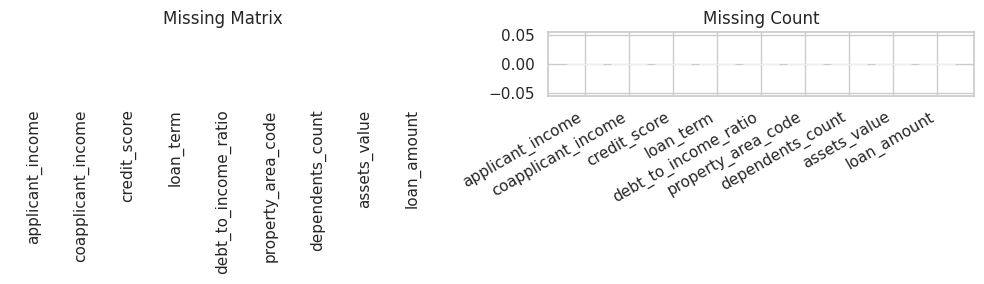

Overall missing rate is 0.00% across all cells
0 column(s) contain missing values


In [41]:
check_missing_values(df_loan, 'loan')

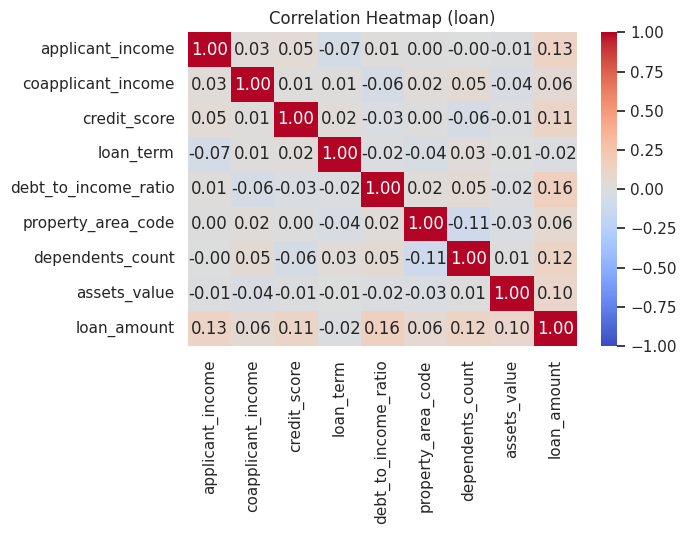

Strongest pairwise correlation is between 'debt_to_income_ratio' and 'loan_amount' (r = 0.16)


In [42]:
plot_correlation(df_loan, 'loan')

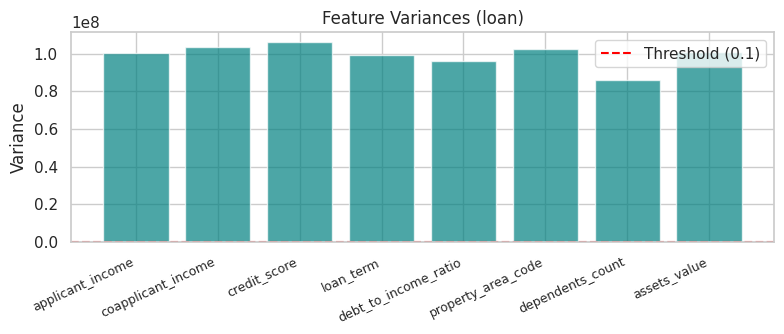

0 of 8 features fall below the variance threshold of 0.1


In [43]:
check_variance(df_loan, 'loan_amount', 'loan')

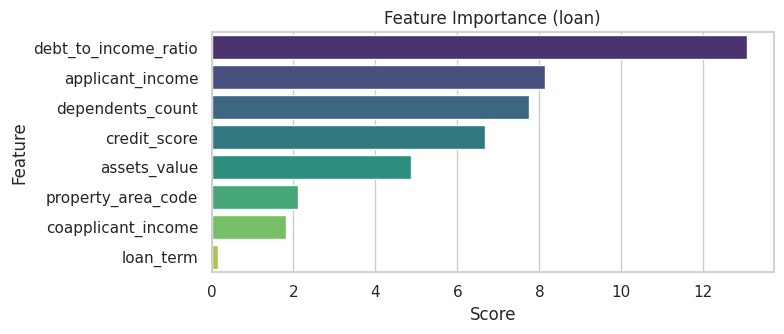

'debt_to_income_ratio' has the strongest relationship with the target (score: 13.07)


In [44]:
rank_features(df_loan, 'loan_amount', f_regression, 'loan')

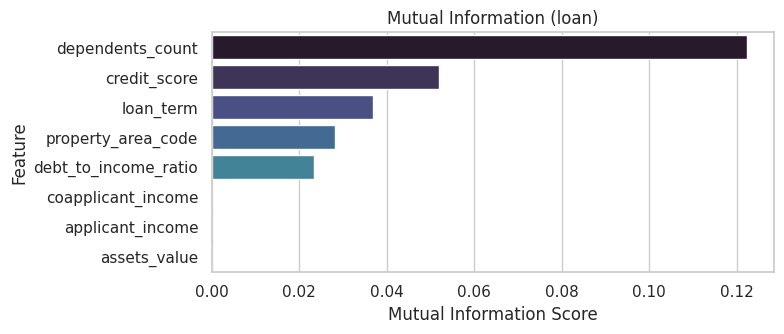

'dependents_count' shares the most information with the target (0.122)


In [45]:
rank_mutual_info(df_loan, 'loan_amount', 'loan', task='regression')

Pair plots are skipped because the target is a continuous number, so there's no category to group the pairplot by. The correlation heatmap and feature importance ranking show the pairwise relationships

#### Cleaning

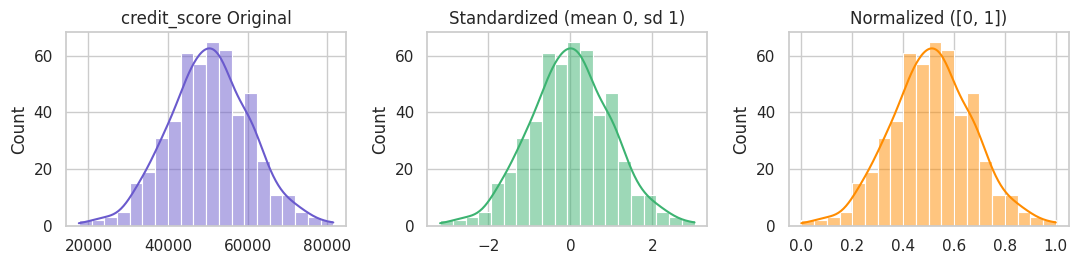

'credit_score' now has mean -0.00/std 1.00 after standardization and range [0, 1] after normalization.


In [46]:
compare_scaling(df_loan, cols_loan[0], 'loan')

### Evaluating Models
basic linear regression, evaluated with R2/RMSE and diagnostic plots

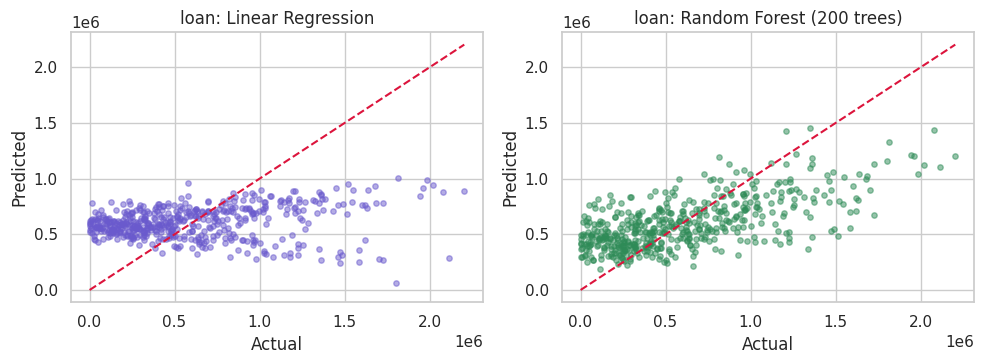

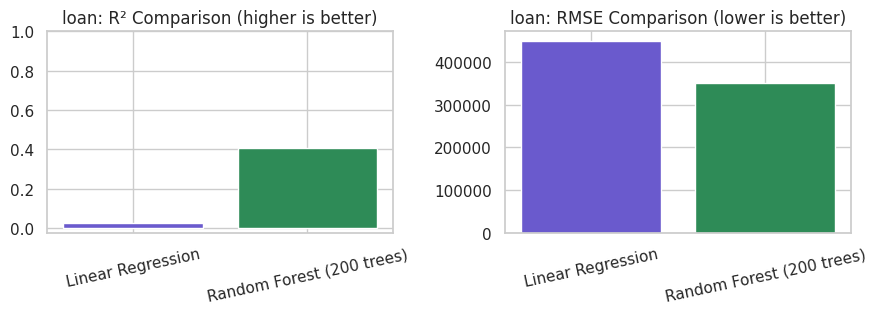

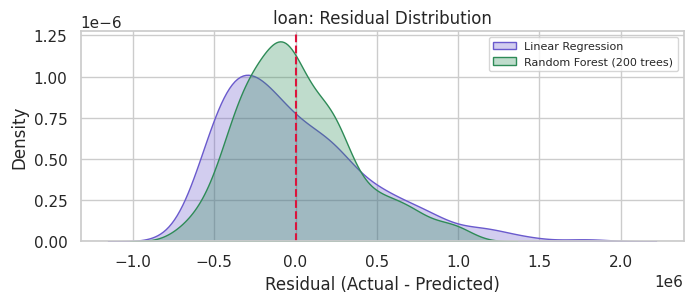

[loan] Linear Regression: R2=0.0276, RMSE=449288.5375 | Random Forest: R2=0.4067, RMSE=350929.7506. 'Random Forest (200 trees)' explains more variance across the 5 folds.
[loan] Overfitting check: Linear Regression train R2 0.0894 vs cross validated R2 0.0276 (gap 0.0619)
[loan] Overfitting check: Random Forest train R2 0.9260 vs cross validated R2 0.4067 (gap 0.5192)


,R2,RMSE
Model,,
Linear Regression,0.0276,449288.5375
Random Forest (200 trees),0.4067,350929.7506


,R2,RMSE
Model,,
Linear Regression,0.027567,449288.537510
Random Forest (200 trees),0.406734,350929.750587


In [47]:
evaluate_regression_linear(df_loan, 'loan_amount', 'loan')

### Spambase dataset(classification) 

In [48]:
cols_spam = pick_key_columns(df_spam, target_col='class', max_cols=5)
print("Selected columns for Spambase:", cols_spam)

Selected columns for Spambase: ['capital_run_length_total', 'capital_run_length_longest', 'capital_run_length_average', 'word_freq_george', 'word_freq_you']


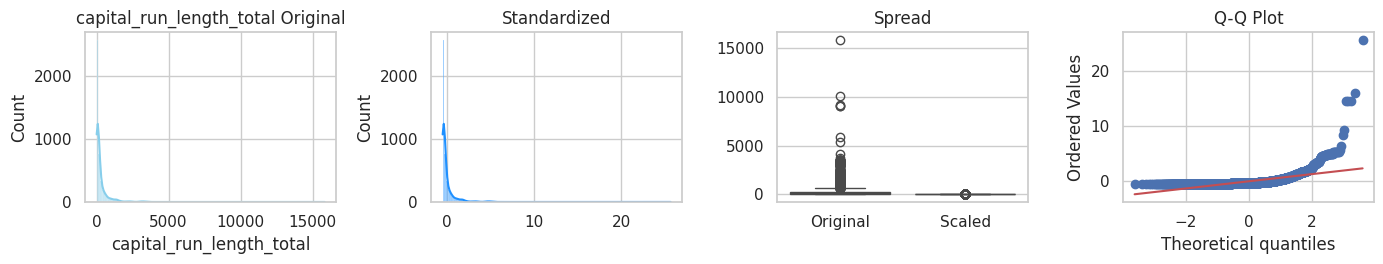

Shapiro-Wilk test on 'capital_run_length_total': p = 0.0000, so the distribution deviates from normality (alpha = 0.05)


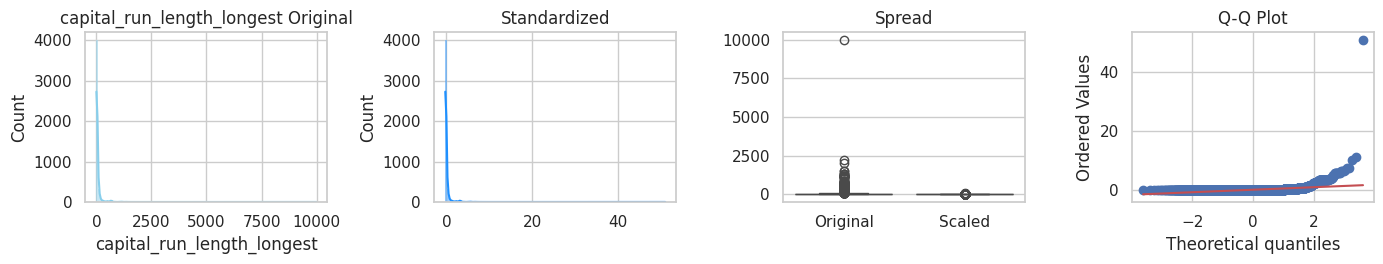

Shapiro-Wilk test on 'capital_run_length_longest': p = 0.0000, so the distribution deviates from normality (alpha = 0.05)


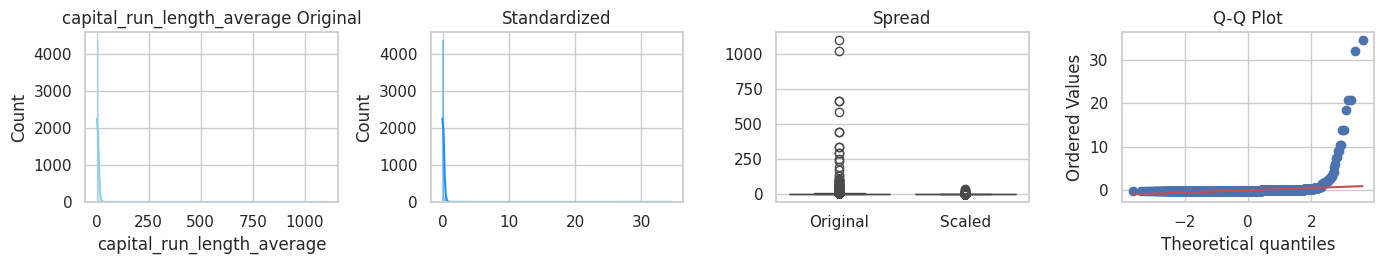

Shapiro-Wilk test on 'capital_run_length_average': p = 0.0000, so the distribution deviates from normality (alpha = 0.05)


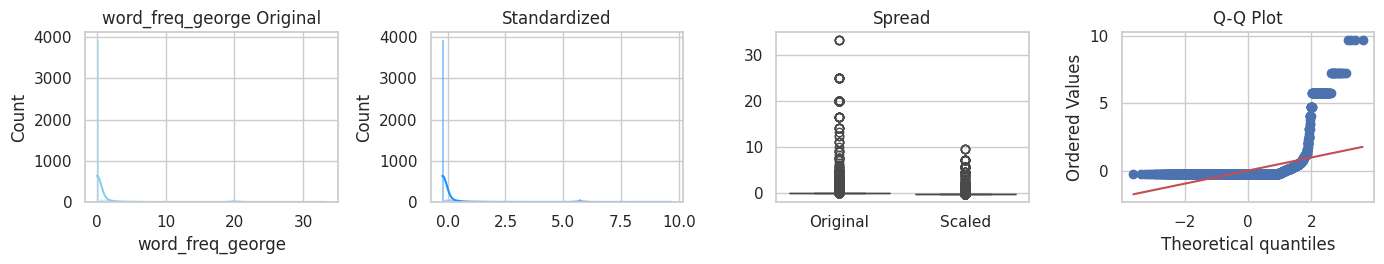

Shapiro-Wilk test on 'word_freq_george': p = 0.0000, so the distribution deviates from normality (alpha = 0.05)


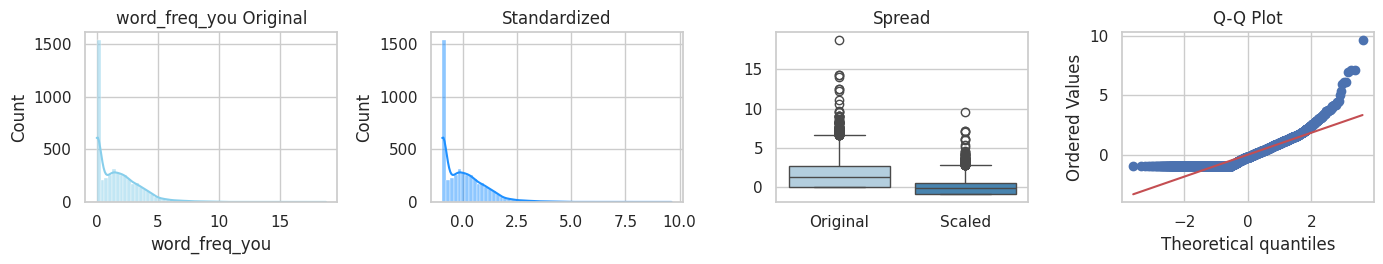

Shapiro-Wilk test on 'word_freq_you': p = 0.0000, so the distribution deviates from normality (alpha = 0.05)


In [49]:
check_normality(df_spam, cols_spam, 'spam')

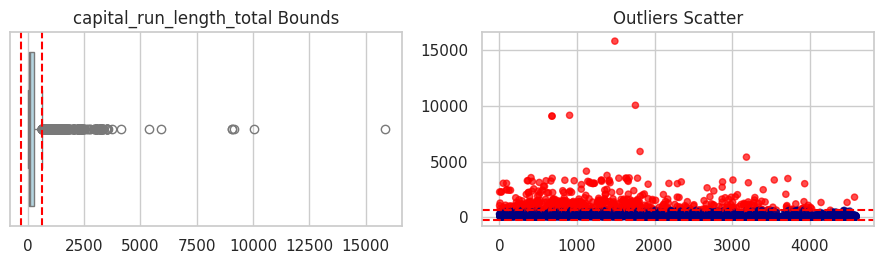

550 of 4601 values in 'capital_run_length_total' are outliers (outside [-311.50, 612.50]).


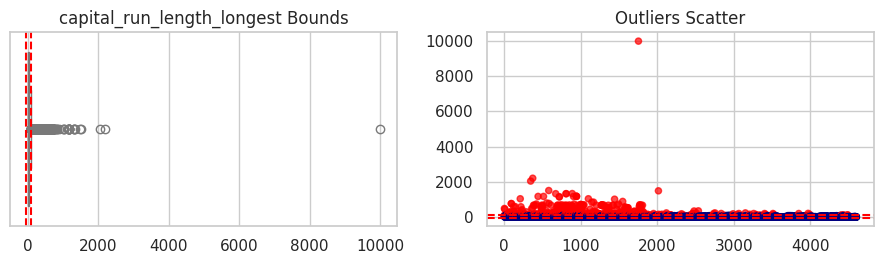

463 of 4601 values in 'capital_run_length_longest' are outliers (outside [-49.50, 98.50]).


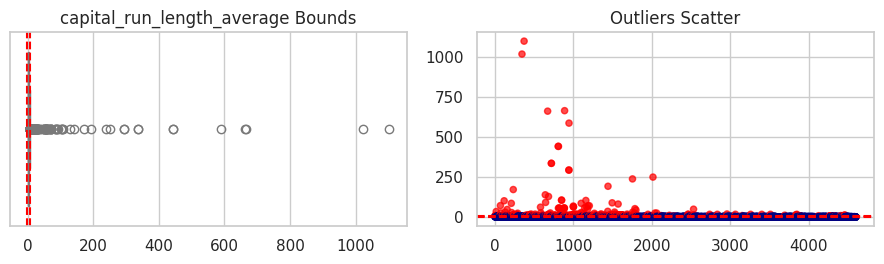

363 of 4601 values in 'capital_run_length_average' are outliers (outside [-1.59, 6.88]).


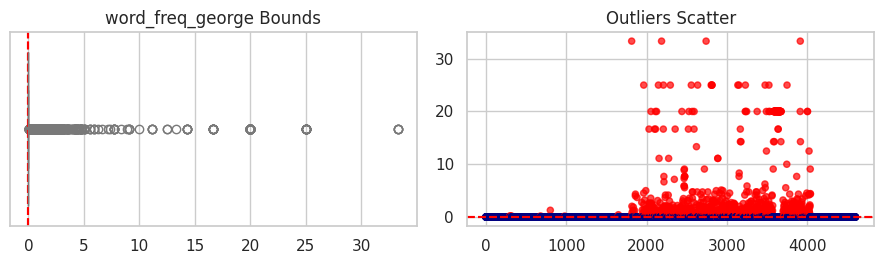

780 of 4601 values in 'word_freq_george' are outliers (outside [0.00, 0.00]).


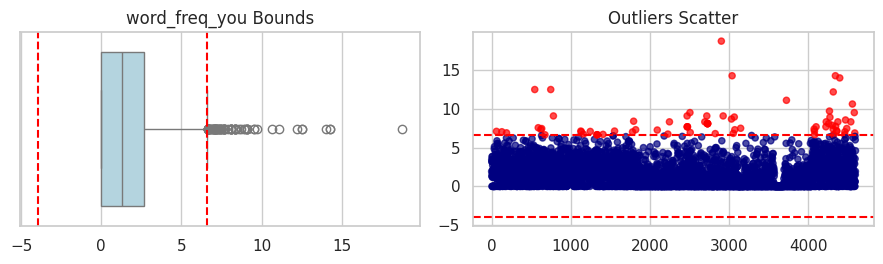

75 of 4601 values in 'word_freq_you' are outliers (outside [-3.96, 6.60]).


In [50]:
find_outliers(df_spam, cols_spam, 'spam')

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


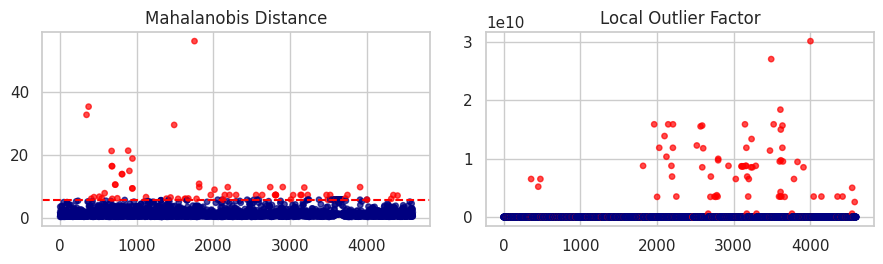

Mahalanobis distance flags 68 points as outliers across correlated features; LOF flags 229 points as locally isolated


In [51]:
find_multivariate_outliers(df_spam, cols_spam, 'spam')

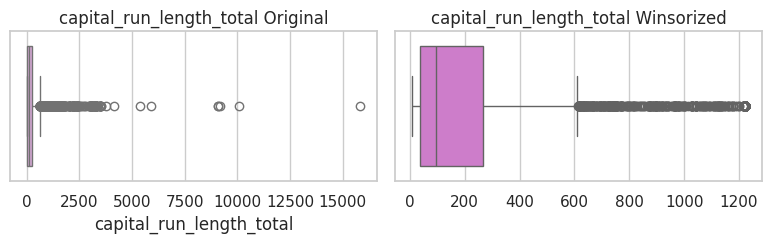

Winsorizing 'capital_run_length_total' capped 9.7% of values, reducing the spread of 15840.00


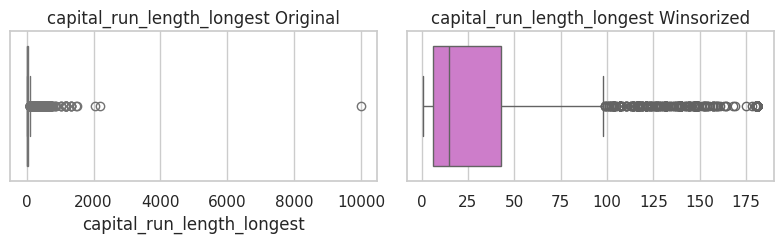

Winsorizing 'capital_run_length_longest' capped 4.9% of values, reducing the spread of 9988.00


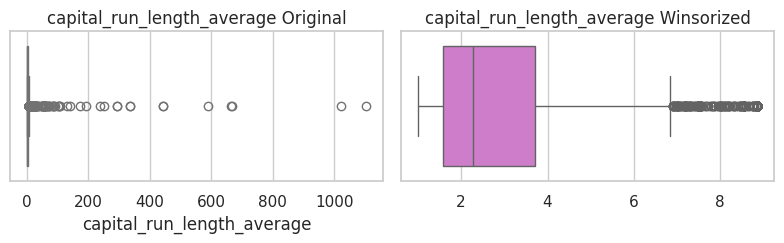

Winsorizing 'capital_run_length_average' capped 5.0% of values, reducing the spread of 1101.50


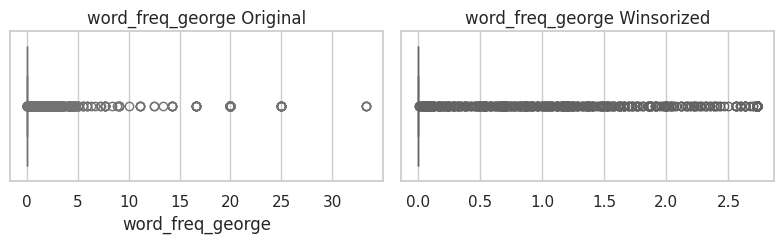

Winsorizing 'word_freq_george' capped 5.0% of values, reducing the spread of 33.33


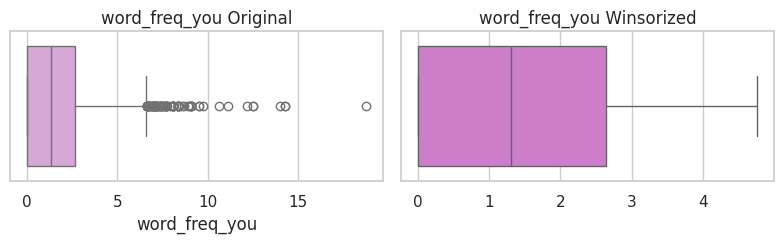

Winsorizing 'word_freq_you' capped 5.0% of values, reducing the spread of 18.75


In [52]:
cap_outliers(df_spam, cols_spam, 'spam')

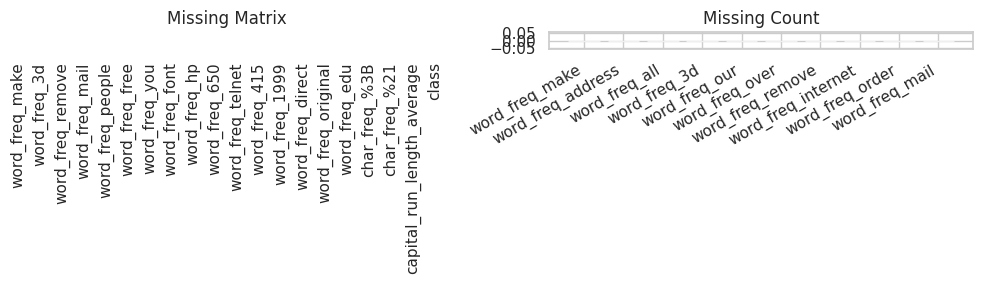

Overall missing rate is 0.00% across all cells
0 column(s) contain missing values


In [53]:
check_missing_values(df_spam, 'spam')

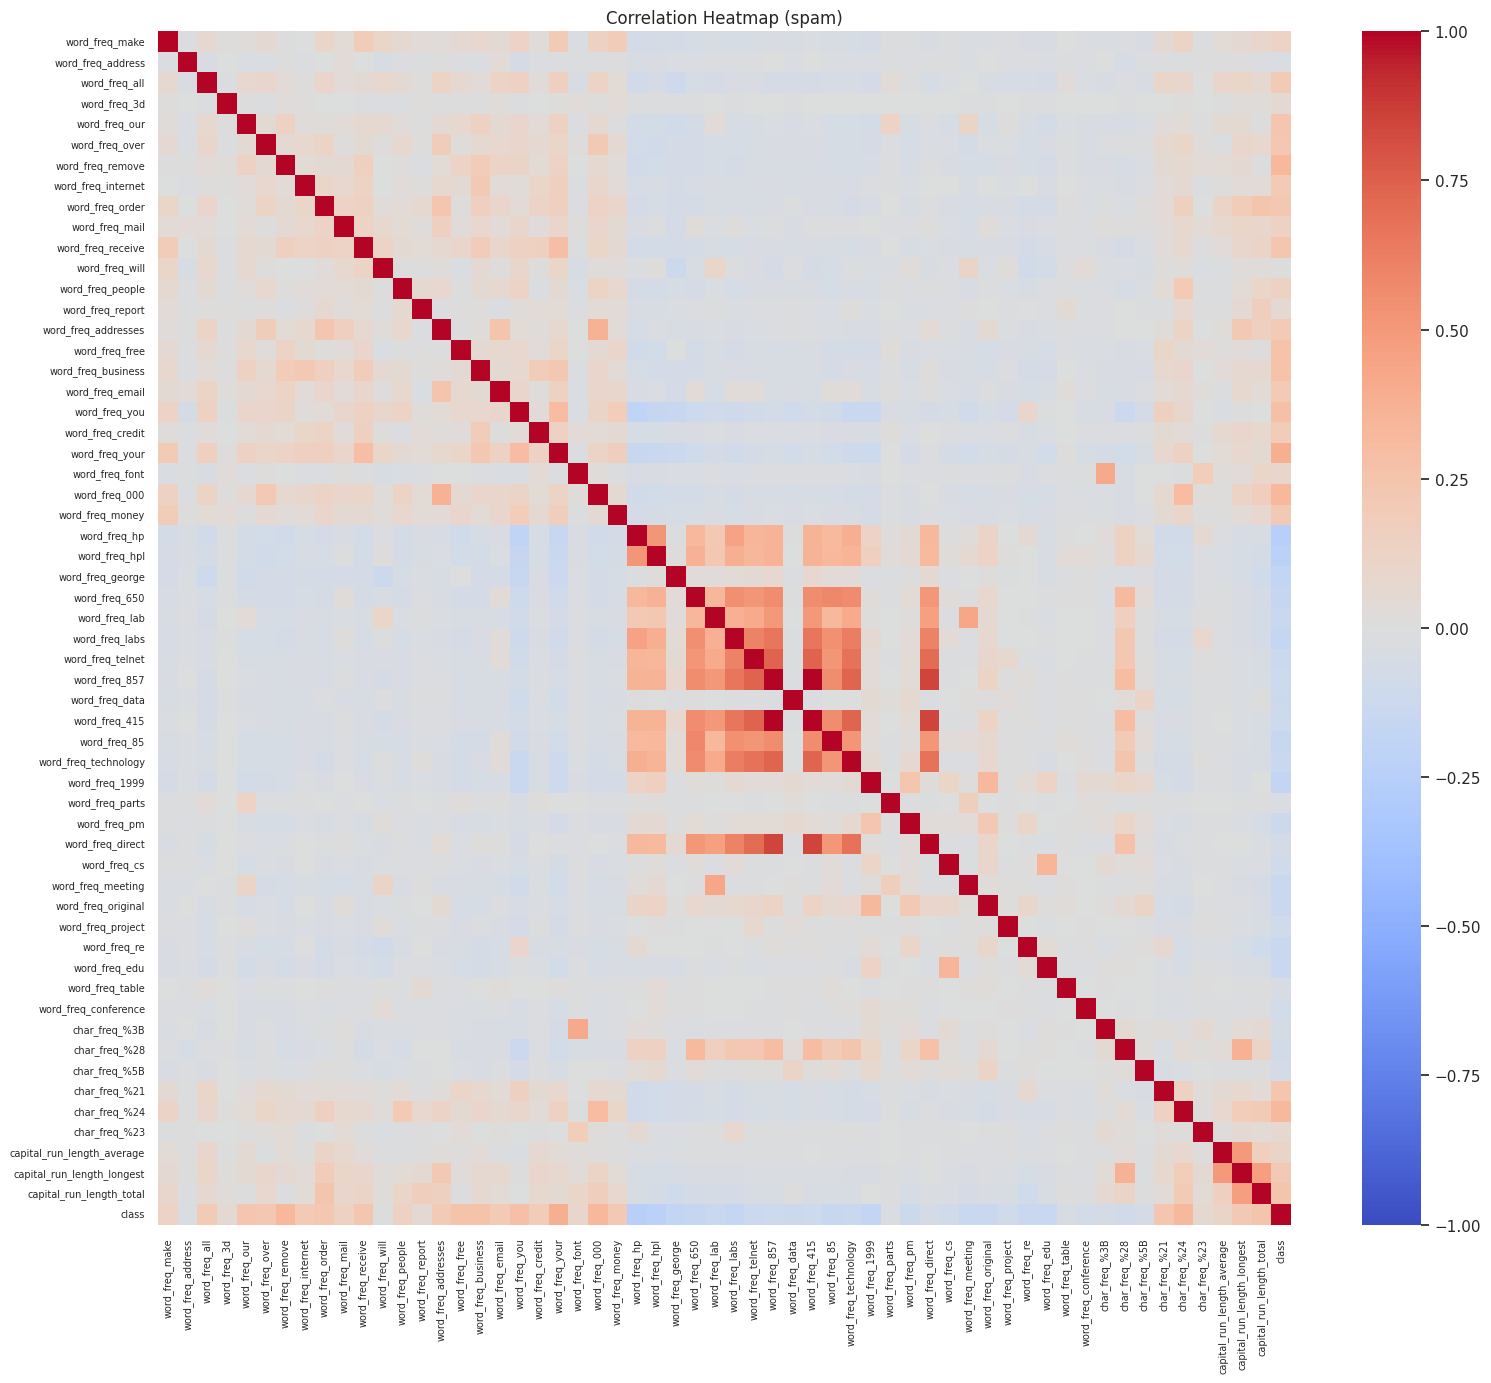

Strongest pairwise correlation is between 'word_freq_857' and 'word_freq_415' (r = 1.00)


In [54]:
plot_correlation(df_spam, 'spam')

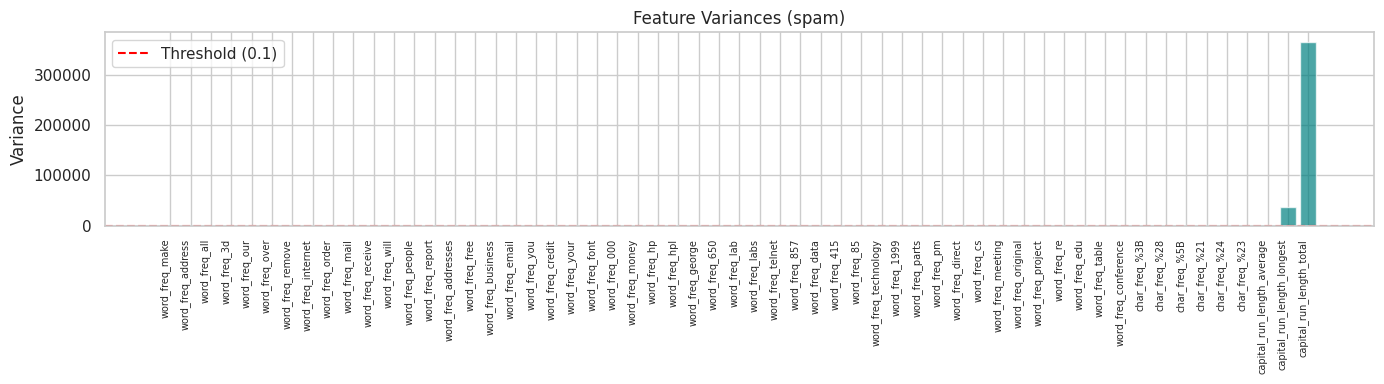

14 of 57 features fall below the variance threshold of 0.1


In [55]:
check_variance(df_spam, 'class', 'spam')

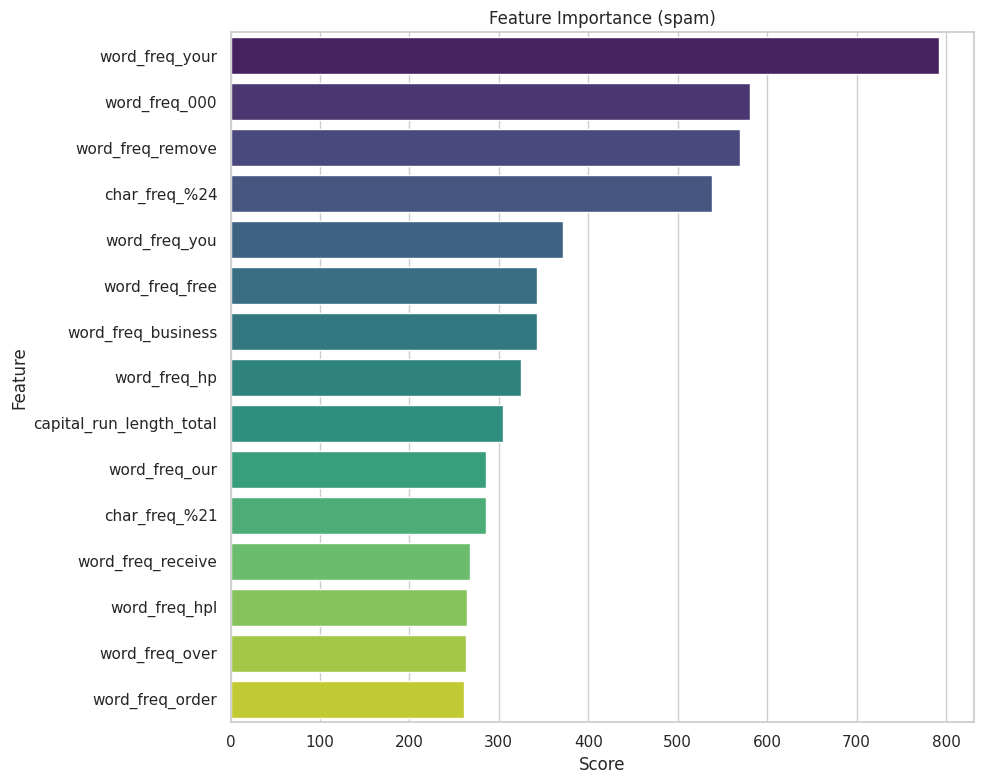

'word_freq_your' has the strongest relationship with the target (score: 791.73)


In [56]:
rank_features(df_spam, 'class', f_classif, 'spam')

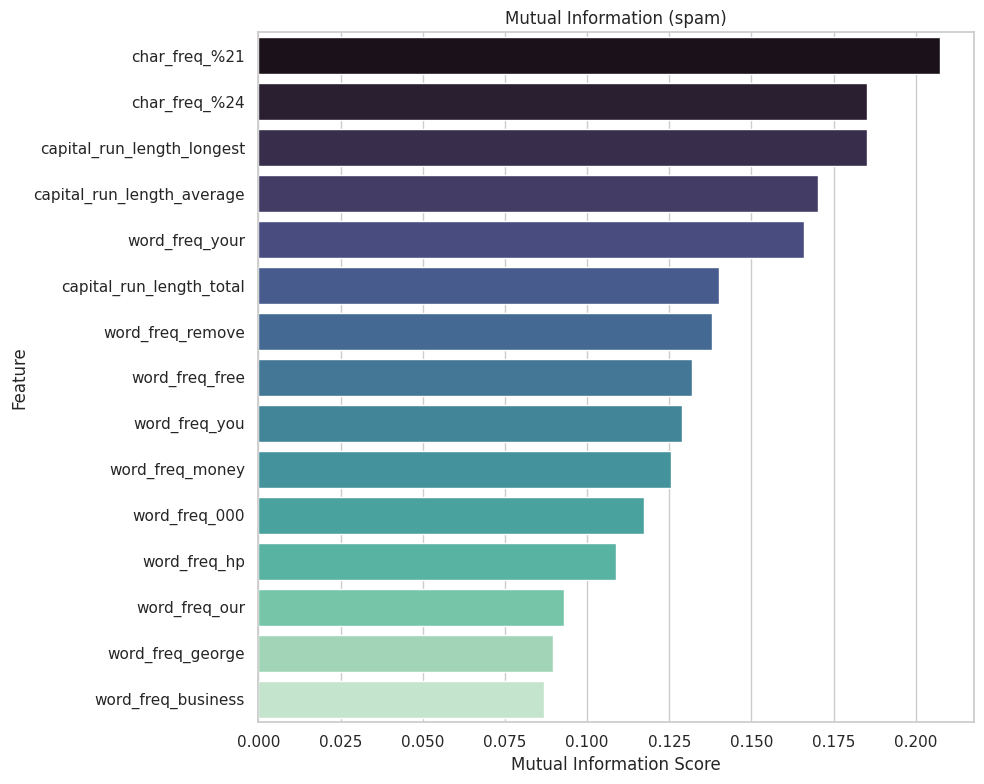

'char_freq_%21' shares the most information with the target (0.207)


In [57]:
rank_mutual_info(df_spam, 'class', 'spam', task='classification')

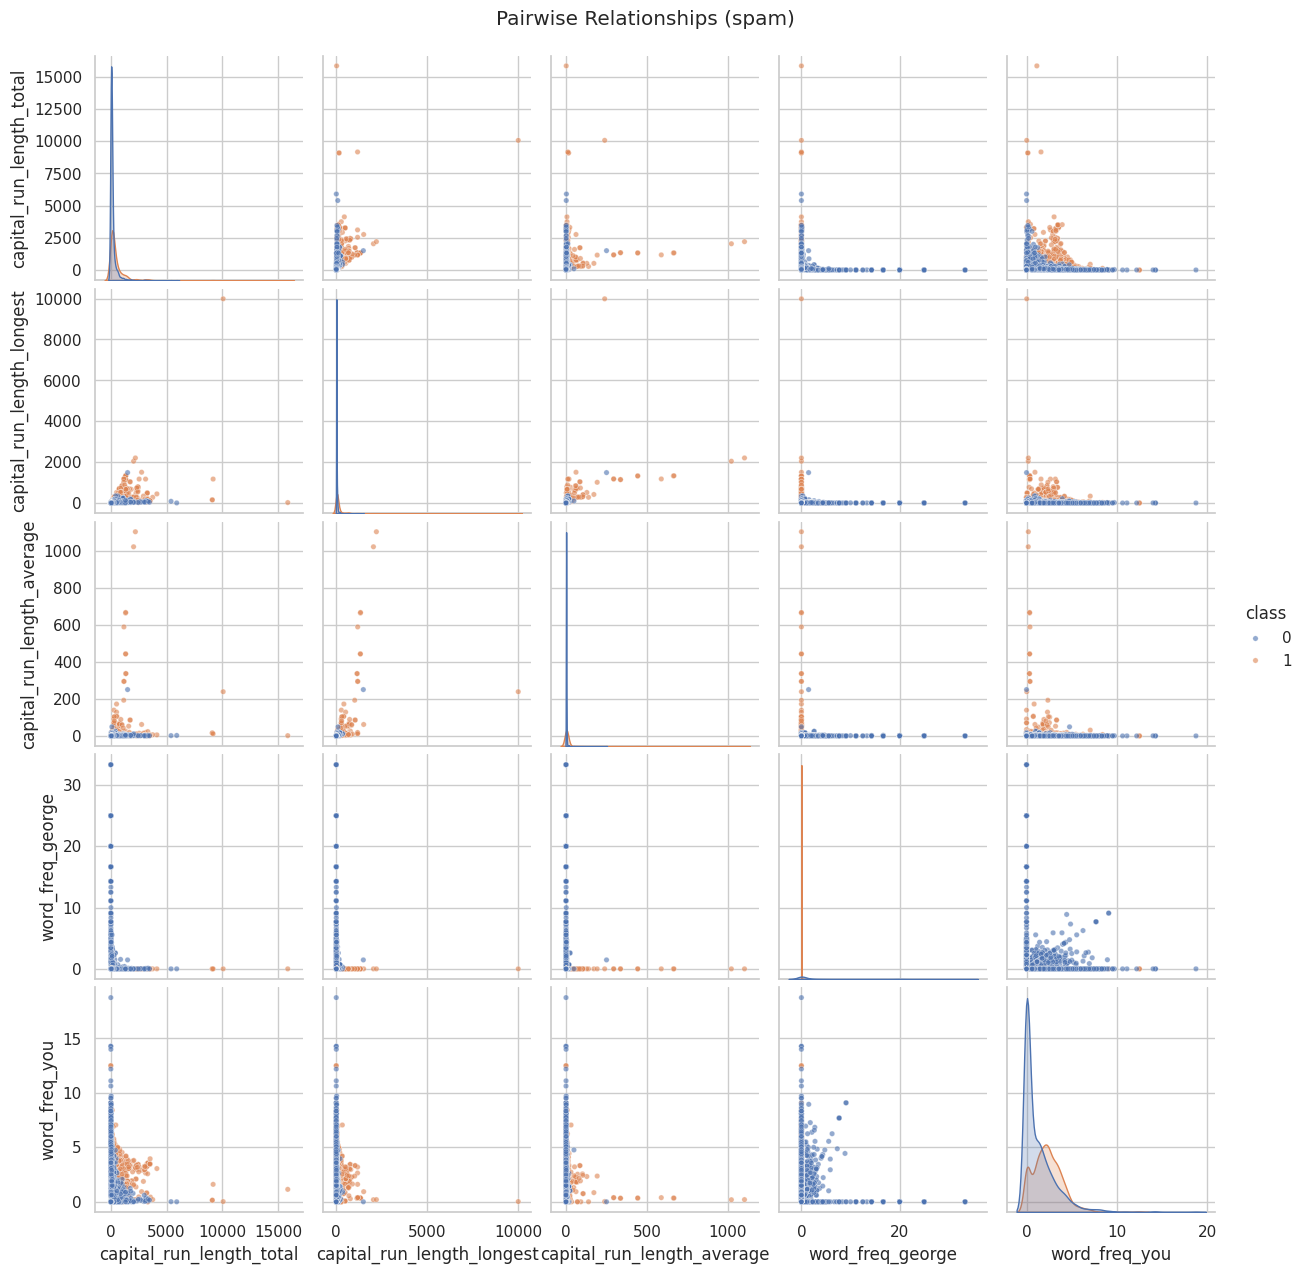

In [58]:
plot_pairwise(df_spam, cols_spam, 'class', 'spam')

#### Cleaning
scaling comparison (standardize vs normalize) on a representative column

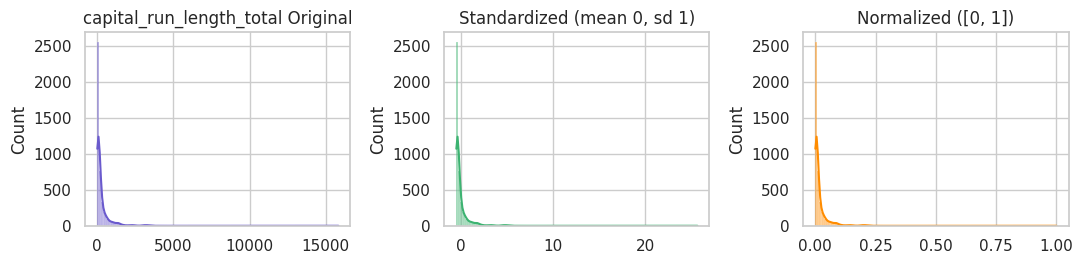

'capital_run_length_total' now has mean 0.00/std 1.00 after standardization and range [0, 1] after normalization.


In [59]:
compare_scaling(df_spam, cols_spam[0], 'spam')

### Evaluating Models
basic KNN classifier, sweeping k and evaluating test accuracy

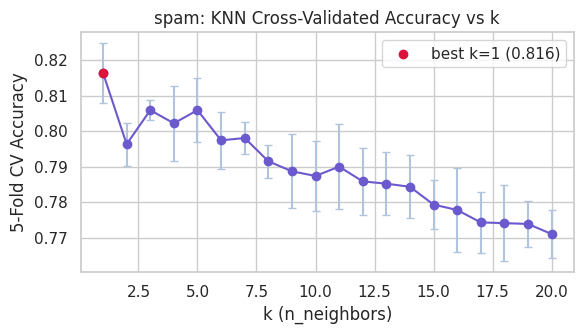

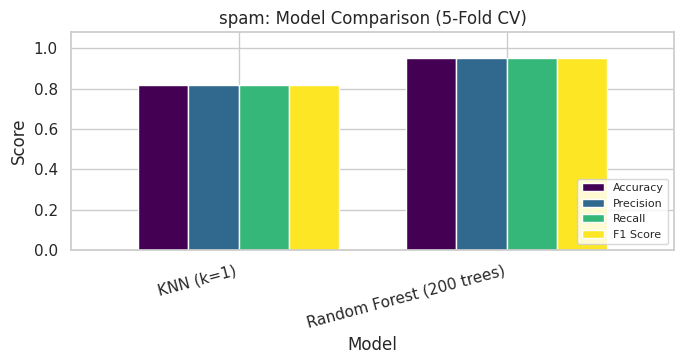

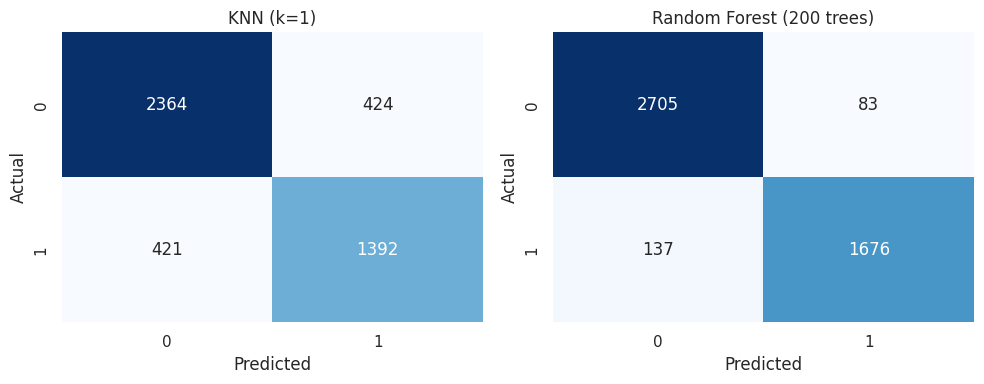

[spam] Best k = 1. 'Random Forest (200 trees)' has the higher cross validated accuracy (0.9522 vs 0.8163).
[spam] Overfitting check: KNN train accuracy 0.9993 vs 5-fold CV accuracy 0.8163 (gap 0.1830)
[spam] Overfitting check: Random Forest train accuracy 0.9993 vs 5-fold CV accuracy 0.9522 (gap 0.0472)


,Accuracy,Precision,Recall,F1 Score
Model,,,,
KNN (k=1),0.8163,0.8164,0.8163,0.8164
Random Forest (200 trees),0.9522,0.9522,0.9522,0.9521


(1,
                            Accuracy  Precision    Recall  F1 Score
 Model                                                             
 KNN (k=1)                  0.816344   0.816398  0.816344  0.816371
 Random Forest (200 trees)  0.952184   0.952196  0.952184  0.952052)

In [60]:
evaluate_classification_knn(df_spam, 'class', 'spam')

### Diabetes dataset (regression)
this is a pre cleaned dataset from scikit-learn which is already standardized

In [61]:
cols_diab = pick_key_columns(df_diab, target_col='target', max_cols=5)
print("Selected columns for Diabetes:", cols_diab)

Selected columns for Diabetes: ['sex', 'age', 's2', 's6', 's4']


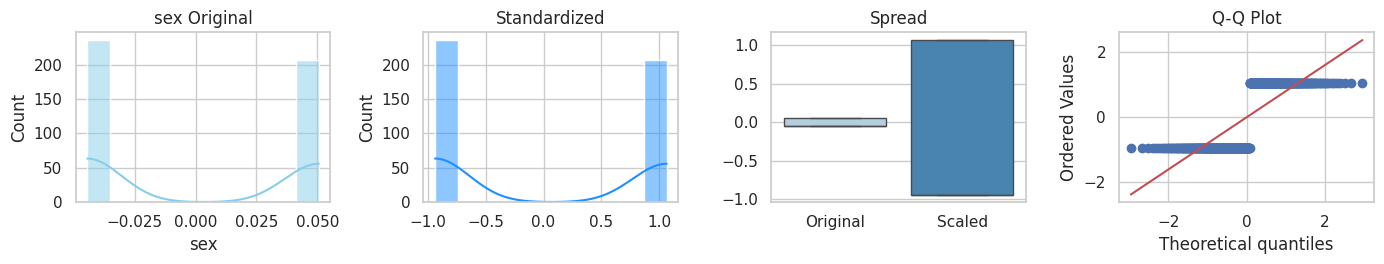

Shapiro-Wilk test on 'sex': p = 0.0000, so the distribution deviates from normality (alpha = 0.05)


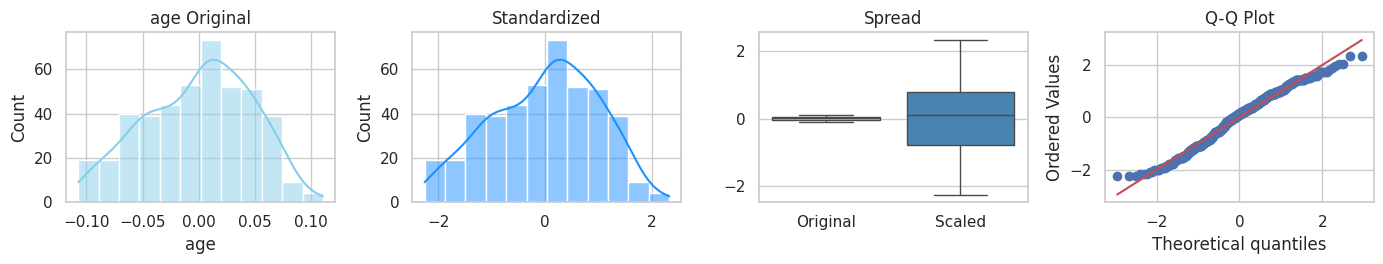

Shapiro-Wilk test on 'age': p = 0.0000, so the distribution deviates from normality (alpha = 0.05)


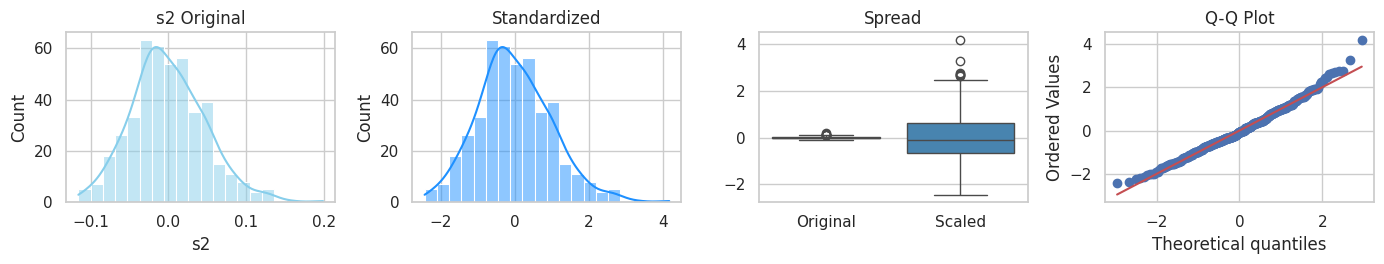

Shapiro-Wilk test on 's2': p = 0.0013, so the distribution deviates from normality (alpha = 0.05)


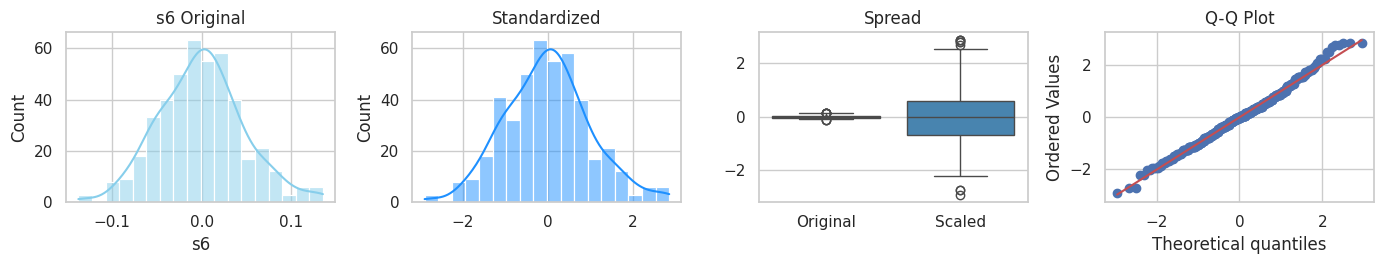

Shapiro-Wilk test on 's6': p = 0.0410, so the distribution deviates from normality (alpha = 0.05)


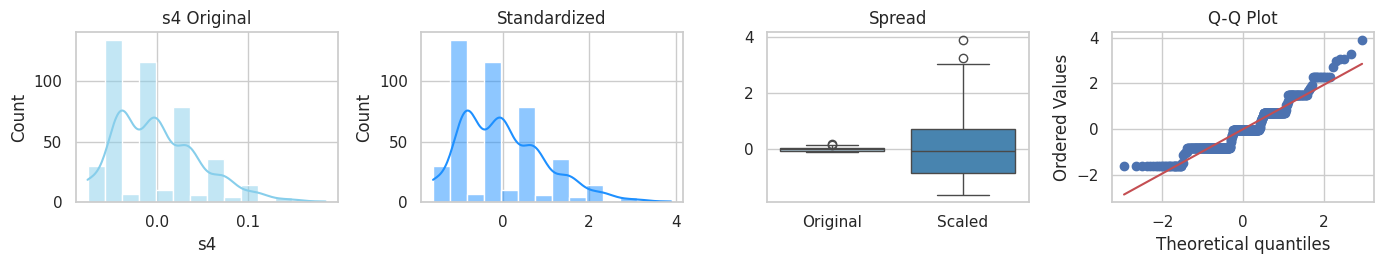

Shapiro-Wilk test on 's4': p = 0.0000, so the distribution deviates from normality (alpha = 0.05)


In [62]:
check_normality(df_diab, cols_diab, 'diab')

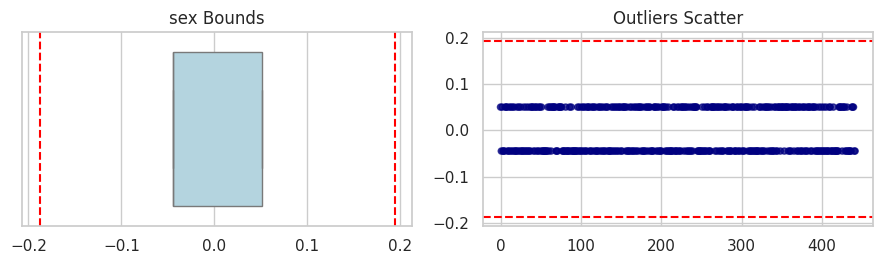

0 of 442 values in 'sex' are outliers (outside [-0.19, 0.19]).


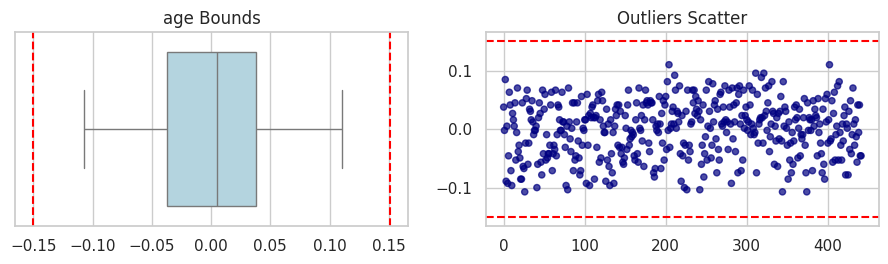

0 of 442 values in 'age' are outliers (outside [-0.15, 0.15]).


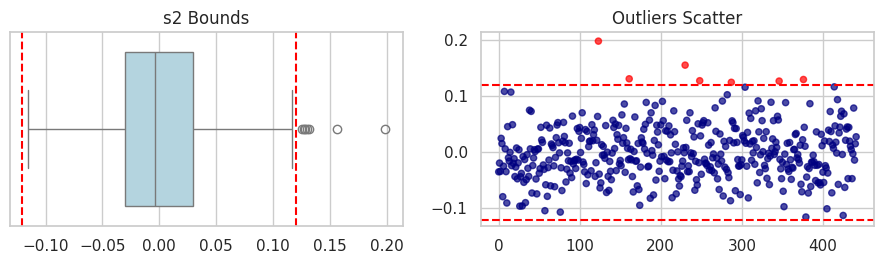

7 of 442 values in 's2' are outliers (outside [-0.12, 0.12]).


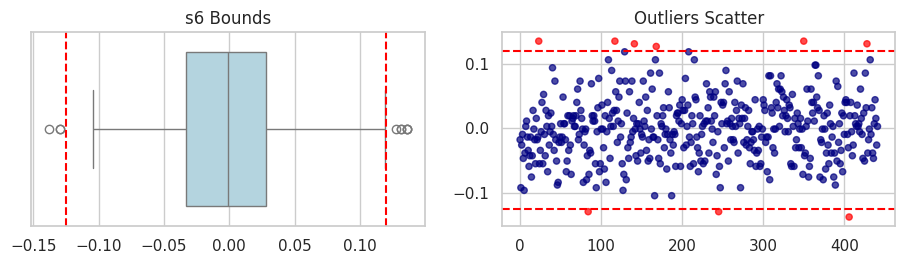

9 of 442 values in 's6' are outliers (outside [-0.12, 0.12]).


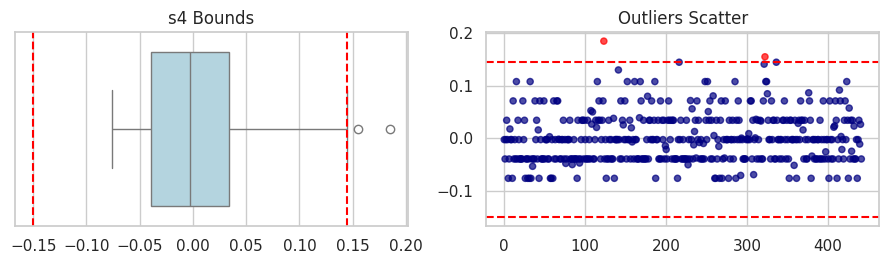

2 of 442 values in 's4' are outliers (outside [-0.15, 0.15]).


In [63]:
find_outliers(df_diab, cols_diab, 'diab')

Winsorization and multivariate outlier detection are skipped because its a pre cleaned, standardized dataset with no missing values, so capping or flagging extreme points would remove variation

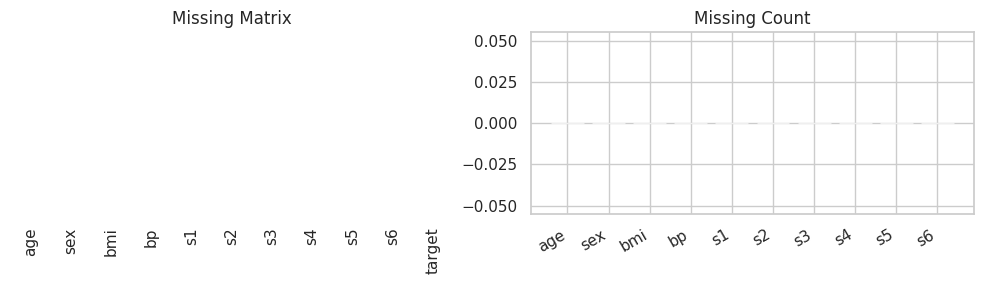

Overall missing rate is 0.00% across all cells
0 column(s) contain missing values


In [64]:
check_missing_values(df_diab, 'diab')

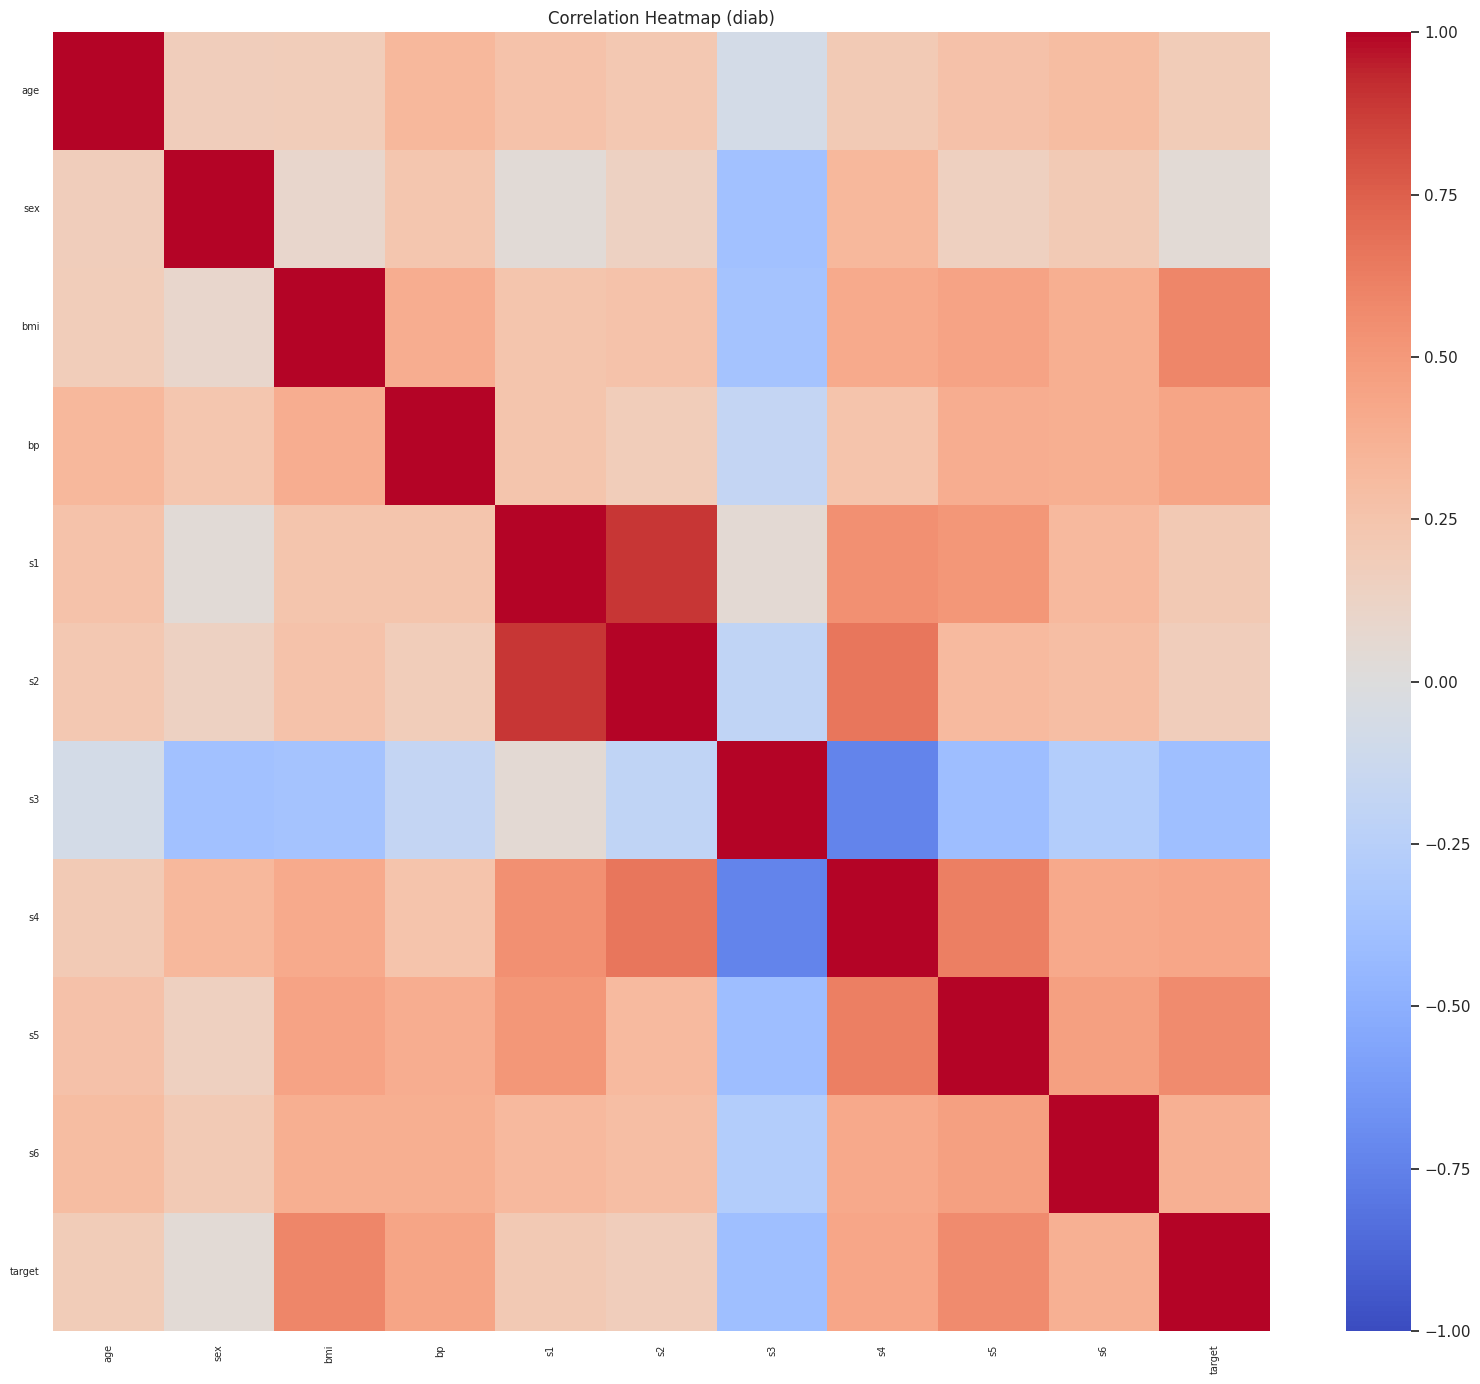

Strongest pairwise correlation is between 's1' and 's2' (r = 0.90)


In [65]:
plot_correlation(df_diab, 'diab')

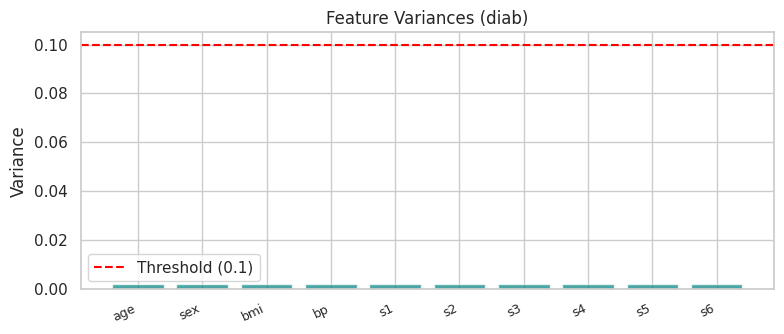

10 of 10 features fall below the variance threshold of 0.1


In [66]:
check_variance(df_diab, 'target', 'diab')

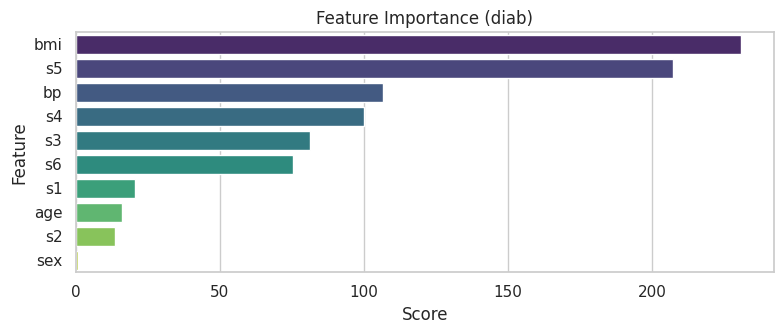

'bmi' has the strongest relationship with the target (score: 230.65)


In [67]:
rank_features(df_diab, 'target', f_regression, 'diab')

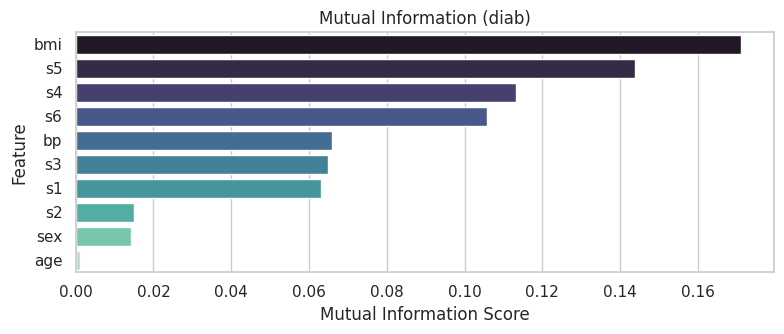

'bmi' shares the most information with the target (0.171)


In [68]:
rank_mutual_info(df_diab, 'target', 'diab', task='regression')

Pair plots are skipped because the target is a continuous disease progression score

#### Cleaning
scaling comparison (standardize vs normalize) on a representative column

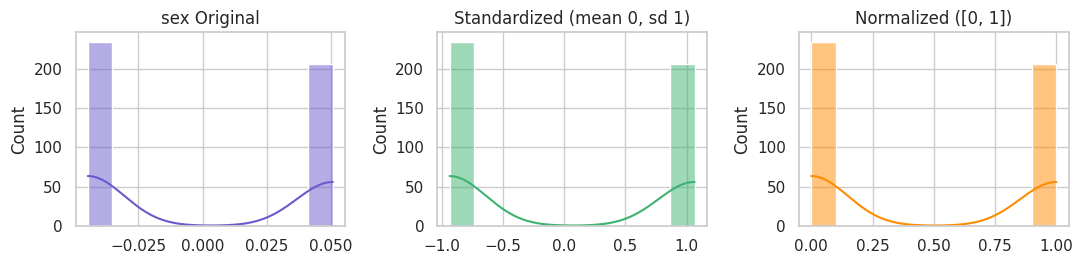

'sex' now has mean 0.00/std 1.00 after standardization and range [0, 1] after normalization.


In [69]:
compare_scaling(df_diab, cols_diab[0], 'diab')

### Evaluating Models
basic linear regression, evaluated with R2/RMSE and diagnostic plots

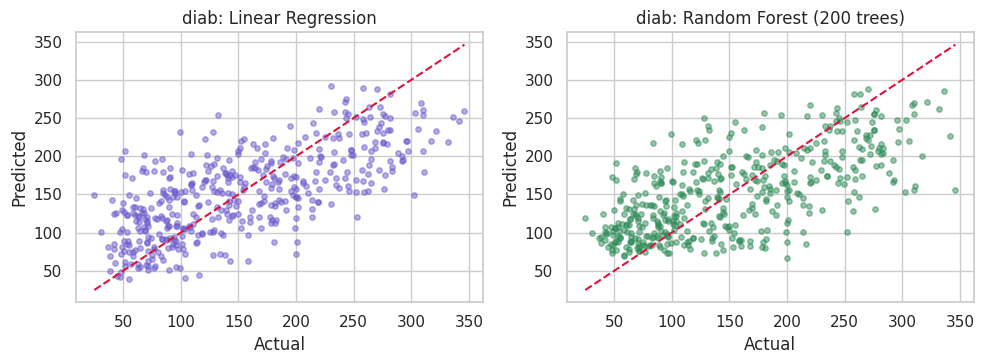

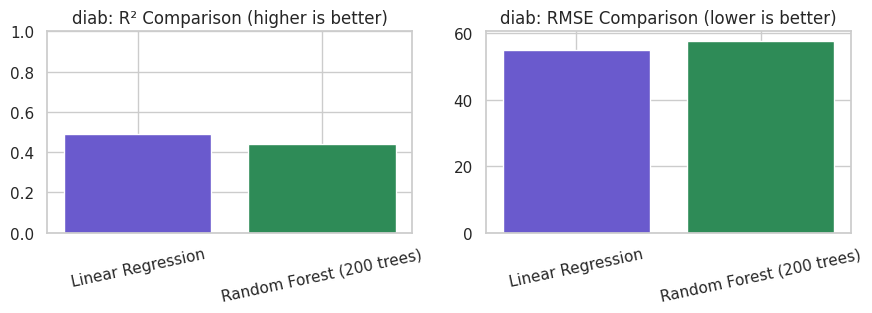

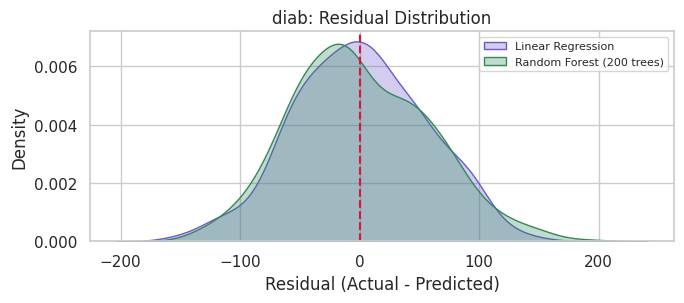

[diab] Linear Regression: R2=0.4917, RMSE=54.9029 | Random Forest: R2=0.4397, RMSE=57.6415. 'Linear Regression' explains more variance across the 5 folds.
[diab] Overfitting check: Linear Regression train R2 0.5177 vs cross validated R2 0.4917 (gap 0.0261)
[diab] Overfitting check: Random Forest train R2 0.9198 vs cross validated R2 0.4397 (gap 0.4801)


,R2,RMSE
Model,,
Linear Regression,0.4917,54.9029
Random Forest (200 trees),0.4397,57.6415


,R2,RMSE
Model,,
Linear Regression,0.491673,54.902851
Random Forest (200 trees),0.439696,57.641468


In [70]:
evaluate_regression_linear(df_diab, 'target', 'diab')

### MNIST dataset (image classification)
This is image data rather than a table of named columns, so the EDA is adapted to fit: instead of per-column normality/outlier checks, we look at class balance, corrupt/missing images, pixel intensity, per-class average images, per-pixel variance, and a PCA summary of how much of the pixel variation a handful of components can capture. A Random Forest classifier is then trained directly on the raw 28x28 (784-pixel) images.

In [71]:
def load_mnist_images(base_dir, split):
    #loads every png under base_dir/split/<digit>/ into a flat 784-length pixel vector,
    #tracking any file that fails to open so we have a real missing/corrupt-data check
    X, y, failed = [], [], 0
    for digit in range(10):
        folder = os.path.join(base_dir, split, str(digit))
        for fname in sorted(os.listdir(folder)):
            try:
                img = Image.open(os.path.join(folder, fname))
                X.append(np.array(img, dtype=np.uint8).reshape(-1))
                y.append(digit)
            except Exception:
                failed += 1
    X = np.array(X, dtype=np.uint8)
    y = np.array(y, dtype=np.int64)
    print(f"Loaded {len(y)} images from '{split}' ({failed} failed to load)")
    return X, y

In [72]:
def check_mnist_integrity(X, dataset='mnist'):
    #image-data analog of check_missing_values: confirms every image loaded, has no NaNs,
    #and that pixel values fall inside the expected 0-255 range
    n_nan = int(np.isnan(X.astype(float)).sum())
    print(f"[{dataset}] {X.shape[0]} images x {X.shape[1]} pixels; "
          f"{n_nan} missing/NaN pixel values; pixel range [{X.min()}, {X.max()}]")

In [73]:
def show_mnist_class_samples(X, y, dataset='mnist'):
    #shows one representative image for every digit class
    fig, axes = plt.subplots(1, 10, figsize=(14, 1.8))
    for digit in range(10):
        idx = np.where(y == digit)[0][0]
        axes[digit].imshow(X[idx].reshape(28, 28), cmap='gray')
        axes[digit].set_title(str(digit), fontsize=10)
        axes[digit].axis('off')
    fig.suptitle(f"{dataset}: One Sample per Class", y=1.05)
    save_plot(dataset, "class_samples")

In [74]:
def plot_mnist_class_distribution(y_train, y_test, dataset='mnist'):
    #train vs test class balance, the image equivalent of a target countplot
    train_counts = pd.Series(y_train).value_counts().sort_index()
    test_counts = pd.Series(y_test).value_counts().sort_index()

    fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
    axes[0].bar(train_counts.index, train_counts.values, color='steelblue')
    axes[0].set_title(f"{dataset}: Train Class Counts")
    axes[0].set_xlabel("Digit")
    axes[0].set_xticks(range(10))
    axes[1].bar(test_counts.index, test_counts.values, color='darkorange')
    axes[1].set_title(f"{dataset}: Test Class Counts")
    axes[1].set_xlabel("Digit")
    axes[1].set_xticks(range(10))
    save_plot(dataset, "class_distribution")

    print(f"[{dataset}] Train counts range from {train_counts.min()} to {train_counts.max()} "
          f"images per digit; classes are roughly balanced")

In [75]:
def plot_mnist_pixel_intensity(X, dataset='mnist'):
    #distribution of raw pixel values, and how much of the image is background vs ink
    rng = np.random.RandomState(0)
    sample = X[rng.choice(len(X), min(5000, len(X)), replace=False)]

    fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
    axes[0].hist(sample.flatten(), bins=50, color='slateblue', alpha=0.85)
    axes[0].set_title(f"{dataset}: Pixel Intensity Distribution")
    axes[0].set_xlabel("Pixel value (0-255)")

    zero_frac = float((sample == 0).mean()) * 100
    axes[1].bar(['Background (0)', 'Ink (>0)'], [zero_frac, 100 - zero_frac], color=['lightgray', 'black'])
    axes[1].set_title("Background vs Ink Pixels")
    axes[1].set_ylabel("% of pixels")
    save_plot(dataset, "pixel_intensity")

    print(f"[{dataset}] {zero_frac:.1f}% of pixels are exactly zero, confirming the images are mostly blank background")

In [76]:
def plot_mnist_mean_images(X, y, dataset='mnist'):
    #average image per digit -- shows the 'prototype' shape the model has to learn to separate
    fig, axes = plt.subplots(1, 10, figsize=(14, 1.8))
    for digit in range(10):
        mean_img = X[y == digit].mean(axis=0).reshape(28, 28)
        axes[digit].imshow(mean_img, cmap='viridis')
        axes[digit].set_title(str(digit), fontsize=10)
        axes[digit].axis('off')
    fig.suptitle(f"{dataset}: Mean Image per Class", y=1.05)
    save_plot(dataset, "mean_images")

In [77]:
def plot_mnist_pixel_variance(X, dataset='mnist', threshold=100):
    #image analog of check_variance: which pixels vary a lot across images (informative)
    #vs which barely change at all (almost always background, so low variance)
    variances = X.astype(float).var(axis=0)

    fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
    im = axes[0].imshow(variances.reshape(28, 28), cmap='hot')
    axes[0].set_title(f"{dataset}: Pixel Variance Map")
    axes[0].axis('off')
    plt.colorbar(im, ax=axes[0], fraction=0.046)

    axes[1].hist(variances, bins=40, color='teal', alpha=0.8)
    axes[1].axvline(threshold, color='red', linestyle='--', label=f'Threshold ({threshold})')
    axes[1].set_title("Variance Distribution")
    axes[1].set_xlabel("Pixel variance")
    axes[1].legend()
    save_plot(dataset, "pixel_variance")

    n_low = int((variances < threshold).sum())
    print(f"[{dataset}] {n_low} of {len(variances)} pixels fall below the variance threshold of {threshold} "
          f"(mostly border pixels that are almost always background)")

In [78]:
def plot_mnist_pca(X, y, dataset='mnist', n_show=3000, n_components=150):
    #image analog of rank_features/rank_mutual_info: since individual raw pixels aren't
    #independently meaningful features, we summarize the 784-dim pixel space with PCA instead
    rng = np.random.RandomState(0)
    idx = rng.choice(len(X), min(n_show, len(X)), replace=False)

    pca_full = PCA(n_components=n_components, random_state=0).fit(X)
    X2 = PCA(n_components=2, random_state=0).fit_transform(X[idx])

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    scatter = axes[0].scatter(X2[:, 0], X2[:, 1], c=y[idx], cmap='tab10', s=8, alpha=0.6)
    axes[0].set_title(f"{dataset}: PCA (2 Components)")
    axes[0].set_xlabel("PC1")
    axes[0].set_ylabel("PC2")
    axes[0].legend(*scatter.legend_elements(), title="Digit", loc='center left',
                   bbox_to_anchor=(1, 0.5), fontsize=7)

    cum_var = np.cumsum(pca_full.explained_variance_ratio_)
    #np.searchsorted (rather than argmax on a boolean mask) correctly finds the first index
    #that reaches 90% even when that happens well past the first few components
    n90 = int(np.searchsorted(cum_var, 0.9)) + 1 if cum_var[-1] >= 0.9 else None

    axes[1].plot(range(1, n_components + 1), cum_var, color='seagreen')
    axes[1].axhline(0.9, color='red', linestyle='--', label='90% variance')
    if n90 is not None:
        axes[1].axvline(n90, color='crimson', linestyle=':', label=f'{n90} components')
    axes[1].set_title("Cumulative Explained Variance")
    axes[1].set_xlabel("# Components")
    axes[1].legend()
    save_plot(dataset, "pca")

    if n90 is not None:
        print(f"[{dataset}] The first {n90} principal components explain 90% of pixel variance, "
              f"out of {X.shape[1]} raw pixel features")
    else:
        print(f"[{dataset}] The first {n_components} principal components only reach "
              f"{cum_var[-1]*100:.1f}% of pixel variance; more components would be needed for 90%")

In [79]:
def evaluate_classification_rf_mnist(X_train, y_train, X_test, y_test, dataset='mnist',
                                      n_range=(10, 25, 50, 75, 100, 150)):
    #sweeps n_estimators (the random forest analog of sweeping k for KNN), plots
    #accuracy vs n_estimators, then evaluates the best forest in depth: metrics,
    #confusion matrix, per-pixel feature importance and misclassified examples
    accuracies = []
    for n in n_range:
        rf = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
        rf.fit(X_train, y_train)
        accuracies.append(accuracy_score(y_test, rf.predict(X_test)))

    best_idx = int(np.argmax(accuracies))
    best_n = n_range[best_idx]

    plt.figure(figsize=(6, 3.5))
    plt.plot(n_range, accuracies, marker='o', color='seagreen')
    plt.scatter([best_n], [accuracies[best_idx]], color='crimson', zorder=5,
                label=f"best n_estimators={best_n} ({accuracies[best_idx]:.3f})")
    plt.xlabel("n_estimators")
    plt.ylabel("Test Accuracy")
    plt.title(f"{dataset}: Random Forest Accuracy vs n_estimators")
    plt.legend()
    save_plot(dataset, "rf_n_estimators_vs_accuracy")

    best_rf = RandomForestClassifier(n_estimators=best_n, random_state=42, n_jobs=-1)
    best_rf.fit(X_train, y_train)
    preds = best_rf.predict(X_test)

    metrics_df = pd.DataFrame({
        "Accuracy": [accuracy_score(y_test, preds)],
        "Precision": [precision_score(y_test, preds, average='weighted', zero_division=0)],
        "Recall": [recall_score(y_test, preds, average='weighted', zero_division=0)],
        "F1 Score": [f1_score(y_test, preds, average='weighted', zero_division=0)],
    }, index=[f"{dataset} Random Forest (n={best_n})"])
    print(f"[{dataset}] Best n_estimators = {best_n}")
    display(metrics_df.style.format("{:.4f}"))

    #confusion matrix
    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{dataset}: Confusion Matrix (Random Forest)")
    save_plot(dataset, "rf_confusion_matrix")

    #per-pixel feature importance, reshaped back into a 28x28 image
    importances = best_rf.feature_importances_.reshape(28, 28)
    plt.figure(figsize=(4.5, 4))
    plt.imshow(importances, cmap='inferno')
    plt.colorbar(fraction=0.046)
    plt.title(f"{dataset}: Pixel Importance (Random Forest)")
    plt.axis('off')
    save_plot(dataset, "rf_feature_importance")

    #a handful of misclassified test images with their true/predicted labels
    wrong_idx = np.where(preds != y_test)[0]
    rng = np.random.RandomState(0)
    show_idx = rng.choice(wrong_idx, min(10, len(wrong_idx)), replace=False)
    fig, axes = plt.subplots(1, len(show_idx), figsize=(1.6 * len(show_idx), 2.0))
    for ax_, i in zip(axes, show_idx):
        ax_.imshow(X_test[i].reshape(28, 28), cmap='gray')
        ax_.set_title(f"T:{y_test[i]} P:{preds[i]}", fontsize=8)
        ax_.axis('off')
    fig.suptitle(f"{dataset}: Misclassified Examples", y=1.1)
    save_plot(dataset, "rf_misclassified")

    print(f"[{dataset}] Random Forest misclassified {len(wrong_idx)} of {len(y_test)} test images "
          f"({100 * len(wrong_idx) / len(y_test):.2f}% error rate)")

    #compare training accuracy against test accuracy to check for overfitting. mnist already
    #ships with a large, held out 10,000 image test set, so unlike the smaller tabular datasets
    #a single split here is trustworthy and cross validation is not really needed
    train_preds = best_rf.predict(X_train)
    train_acc = accuracy_score(y_train, train_preds)
    test_acc = accuracy_score(y_test, preds)
    print(f"[{dataset}] Overfitting check: train accuracy {train_acc:.4f} vs test accuracy {test_acc:.4f} "
          f"(gap {train_acc - test_acc:.4f})")

    return best_n, metrics_df

In [80]:
t0 = time.time()
X_mnist_train, y_mnist_train = load_mnist_images('mnist_images', 'train')
X_mnist_test, y_mnist_test = load_mnist_images('mnist_images', 'test')
print(f"MNIST train: {X_mnist_train.shape}, test: {X_mnist_test.shape} (loaded in {time.time() - t0:.1f}s)")

Loaded 60000 images from 'train' (0 failed to load)


Loaded 10000 images from 'test' (0 failed to load)
MNIST train: (60000, 784), test: (10000, 784) (loaded in 5.3s)


In [81]:
check_mnist_integrity(X_mnist_train, 'mnist-train')
check_mnist_integrity(X_mnist_test, 'mnist-test')

[mnist-train] 60000 images x 784 pixels; 0 missing/NaN pixel values; pixel range [0, 255]
[mnist-test] 10000 images x 784 pixels; 0 missing/NaN pixel values; pixel range [0, 255]


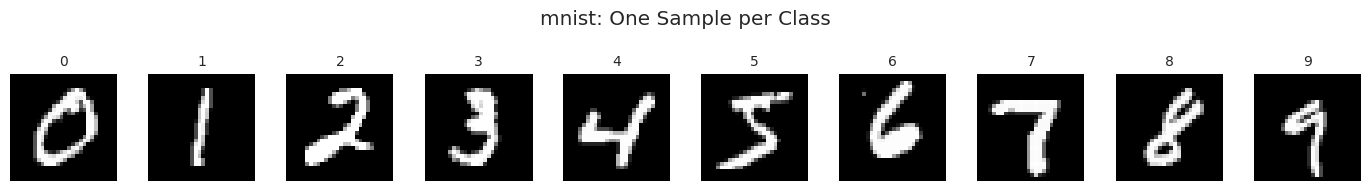

In [82]:
show_mnist_class_samples(X_mnist_train, y_mnist_train, 'mnist')

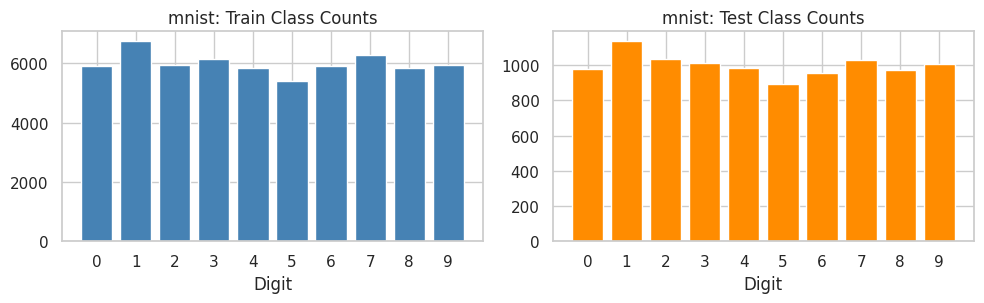

[mnist] Train counts range from 5421 to 6742 images per digit; classes are roughly balanced


In [83]:
plot_mnist_class_distribution(y_mnist_train, y_mnist_test, 'mnist')

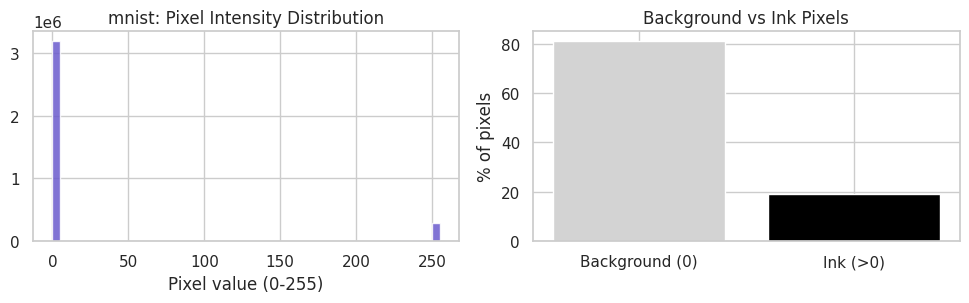

[mnist] 80.9% of pixels are exactly zero, confirming the images are mostly blank background


In [84]:
plot_mnist_pixel_intensity(X_mnist_train, 'mnist')

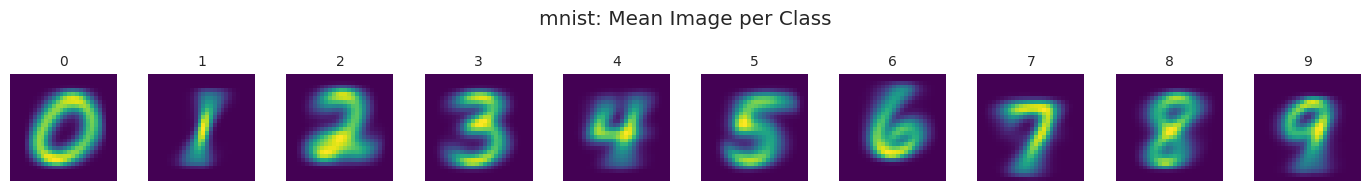

In [85]:
plot_mnist_mean_images(X_mnist_train, y_mnist_train, 'mnist')

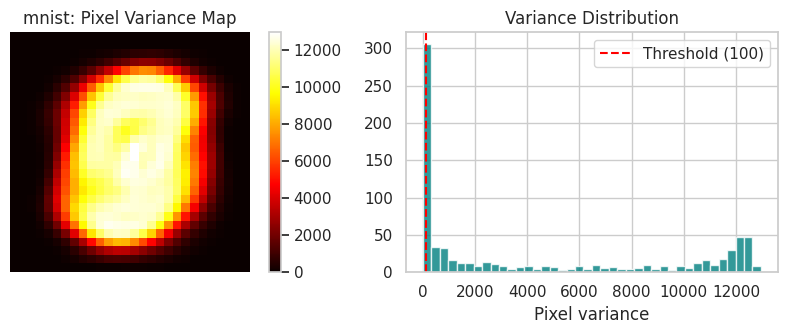

[mnist] 262 of 784 pixels fall below the variance threshold of 100 (mostly border pixels that are almost always background)


In [86]:
plot_mnist_pixel_variance(X_mnist_train, 'mnist')

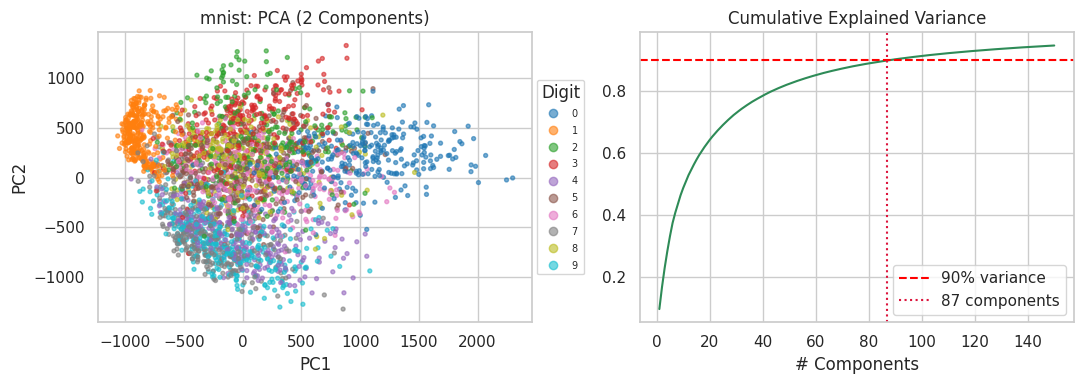

[mnist] The first 87 principal components explain 90% of pixel variance, out of 784 raw pixel features


In [87]:
plot_mnist_pca(X_mnist_train, y_mnist_train, 'mnist')

#### Cleaning
Raw pixel values are already on a common, bounded [0, 255] scale and Random Forests split on raw feature values, so no scaling is required for the model itself. For consistency with the other datasets' cleaning step, `compare_scaling` is still demonstrated below on a derived per-image feature (mean pixel intensity, i.e. how much ink is on the page).

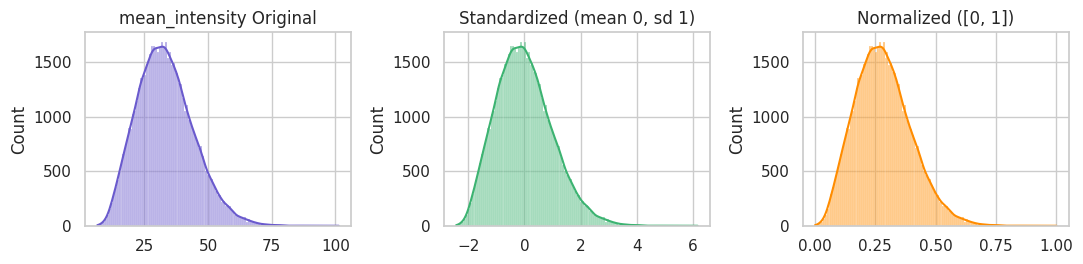

'mean_intensity' now has mean -0.00/std 1.00 after standardization and range [0, 1] after normalization.


In [88]:
df_mnist_summary = pd.DataFrame({
    'mean_intensity': X_mnist_train.mean(axis=1),
    'digit': y_mnist_train,
})
compare_scaling(df_mnist_summary, 'mean_intensity', 'mnist')

### Evaluating Models
Random Forest classifier trained directly on raw pixels, sweeping `n_estimators` the same way the other datasets sweep KNN's `k`, then evaluated with a confusion matrix, per-pixel feature importance and a look at misclassified digits.

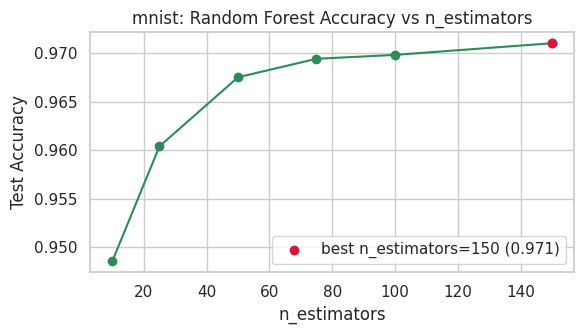

[mnist] Best n_estimators = 150


,Accuracy,Precision,Recall,F1 Score
mnist Random Forest (n=150),0.9710,0.9710,0.9710,0.9710


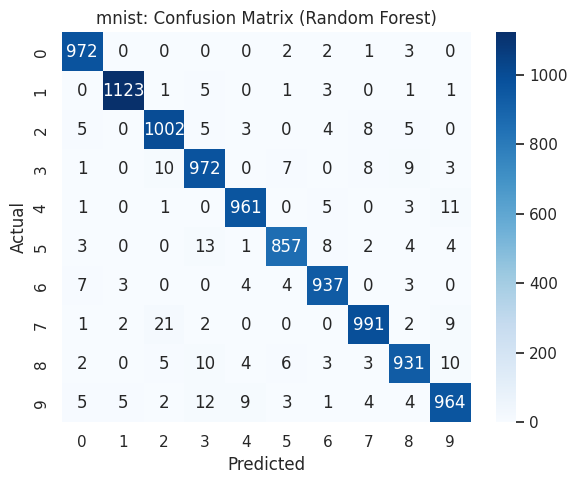

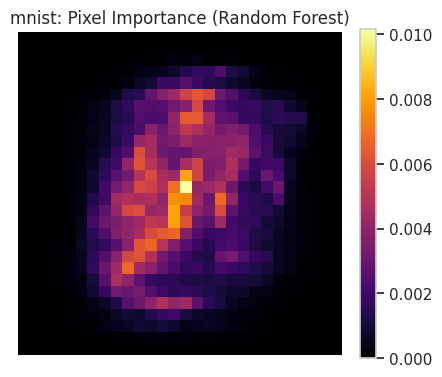

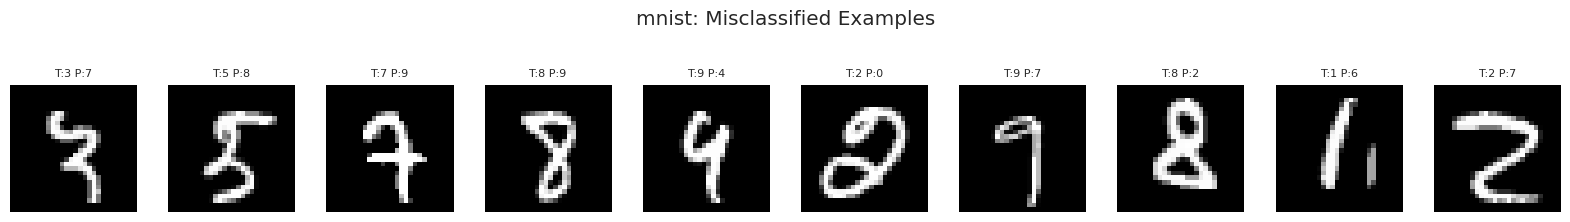

[mnist] Random Forest misclassified 290 of 10000 test images (2.90% error rate)


[mnist] Overfitting check: train accuracy 1.0000 vs test accuracy 0.9710 (gap 0.0290)


In [89]:
best_n_mnist, mnist_metrics = evaluate_classification_rf_mnist(
    X_mnist_train, y_mnist_train, X_mnist_test, y_mnist_test, 'mnist'
)

`fill_missing_values` and `encode_categories` aren't used because `check_missing_values` confirmed 0% missing values across all four tabular datasets (Iris, Loan Amount, Spambase, Diabetes), all of which are already fully numeric with no categorical columns. `check_mnist_integrity` similarly confirmed 0 missing/corrupt images and 0 NaN pixel values for the fifth dataset, MNIST, so no additional cleaning was needed there either.

In [90]:
print("done")

done
